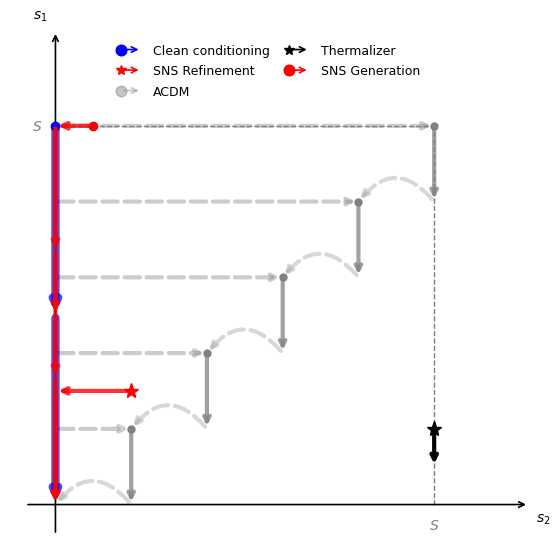

In [141]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerBase

# =========================
# USER CONTROLS
# =========================

CLEAN_LW   = 6
ANNEAL_LW  = 3
SNS_LW     = 3

CLEAN_ALPHA  = 0.7
ANNEAL_ALPHA = 0.45
SNS_ALPHA    = 0.8

ANNEAL_H_ALPHA = 0.4
SNS_H1_ALPHA   = 0.4
SNS_H2_ALPHA   = 0.4

ANNEAL_DOWN_ALPHA = 0.75
ANNEAL_DASH_ALPHA = 0.30

CONSTRAINT_ALPHA = 0.5
CONSTRAINT_LW    = 1.0

CLEAN_Z  = 6
ANNEAL_Z = 4
SNS_Z    = 8

ANNEAL_STEP   = 0.2
ANNEAL_DOT_MS = 5

# =========================


class HandlerMarkerArrow(HandlerBase):
    """
    Legend handler that draws an arrow AND a start-marker.
    - Arrow edge/face colors are taken from the proxy handle.
    - Marker color follows the arrow edgecolor.
    """
    def __init__(self, arrowstyle='->', lw=1.2, marker='o', **kwargs):
        super().__init__(**kwargs)
        self.arrowstyle = arrowstyle
        self.lw = lw
        self.marker = marker

    def _as_rgba(self, c):
        # FancyArrowPatch can return facecolor as (4,) or (1,4)
        try:
            if hasattr(c, "__len__") and len(c) == 1 and hasattr(c[0], "__len__") and len(c[0]) == 4:
                return c[0]
        except Exception:
            pass
        return c

    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        edge = self._as_rgba(orig_handle.get_edgecolor())
        face = self._as_rgba(orig_handle.get_facecolor())

        y = ydescent + height / 2.0
        x0 = xdescent + 0.10 * width
        x1 = xdescent + 0.95 * width

        arrow = FancyArrowPatch(
            (x0, y), (x1, y),
            arrowstyle=self.arrowstyle,
            mutation_scale=fontsize * 1.1,
            linewidth=self.lw,
            edgecolor=edge,
            facecolor=face,
            transform=trans
        )

        marker = plt.Line2D(
            [x0], [y],
            marker=self.marker,
            markersize=fontsize * 0.85,
            color=edge,
            linestyle='None',
            transform=trans
        )
        return [arrow, marker]


def segmented_arrow(ax, p0, p1, n=4, zorder=None, **arrowprops):
    x0, y0 = p0
    x1, y1 = p1
    for i in range(n):
        xa = x0 + (x1 - x0) * i / n
        ya = y0 + (y1 - y0) * i / n
        xb = x0 + (x1 - x0) * (i + 1) / n
        yb = y0 + (y1 - y0) * (i + 1) / n
        ax.annotate('', xy=(xb, yb), xytext=(xa, ya),
                    arrowprops=arrowprops, zorder=zorder)


fig, ax = plt.subplots(figsize=(6, 6))

ax.set_xlim(-0.12, 1.25)
ax.set_ylim(-0.12, 1.25)
ax.set_aspect('equal', adjustable='box')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# ---- Axes ----
neg = -0.08
ax.annotate('', xy=(1.25, 0), xytext=(neg, 0),
            arrowprops=dict(arrowstyle='->', linewidth=1.2, color='black'),
            clip_on=False, zorder=0)
ax.annotate('', xy=(0, 1.25), xytext=(0, neg),
            arrowprops=dict(arrowstyle='->', linewidth=1.2, color='black'),
            clip_on=False, zorder=0)

ax.text(1.27, -0.02, r'$s_2$', ha='left', va='top')
ax.text(-0.02, 1.27, r'$s_1$', ha='right', va='bottom')

# ---- Constraints ----
ax.plot([0, 1], [1, 1], '--', color='black',
        alpha=CONSTRAINT_ALPHA, linewidth=CONSTRAINT_LW, zorder=1)
ax.plot([1, 1], [0, 1], '--', color='black',
        alpha=CONSTRAINT_ALPHA, linewidth=CONSTRAINT_LW, zorder=1)

ax.text(-0.035, 1.0, r'$S$', ha='right', va='center',
        alpha=CONSTRAINT_ALPHA)
ax.text(1.0, -0.035, r'$S$', ha='center', va='top',
        alpha=CONSTRAINT_ALPHA)

# ---- Clean conditioning ----
ax.plot(0, 1, 'o', color='blue', zorder=CLEAN_Z + 1)
ax.annotate('', xy=(0, 0.5), xytext=(0, 1),
            arrowprops=dict(arrowstyle='->', color='blue',
                            linewidth=CLEAN_LW, alpha=CLEAN_ALPHA),
            zorder=CLEAN_Z)
ax.annotate('', xy=(0, 0), xytext=(0, 0.5),
            arrowprops=dict(arrowstyle='->', color='blue',
                            linewidth=CLEAN_LW, alpha=CLEAN_ALPHA),
            zorder=CLEAN_Z)

# ---- Annealed conditioning ----
grey = (0.5, 0.5, 0.5)

levels     = [1.0, 0.8, 0.6, 0.4, 0.2]
hop_levels = [0.8, 0.6, 0.4, 0.2]

# Horizontal (dashed)
for s in levels:
    ax.annotate('', xy=(s, s), xytext=(0, s),
                arrowprops=dict(arrowstyle='->',
                                color=(*grey, ANNEAL_H_ALPHA),
                                linewidth=ANNEAL_LW,
                                linestyle='--'),
                zorder=ANNEAL_Z)

# Down arrows
for s in levels:
    ax.plot(s, s, 'o', color=grey, markersize=ANNEAL_DOT_MS,
            zorder=ANNEAL_Z + 2)
    ax.annotate('', xy=(s, s - ANNEAL_STEP), xytext=(s, s),
                arrowprops=dict(arrowstyle='->',
                                color=(*grey, ANNEAL_DOWN_ALPHA),
                                linewidth=ANNEAL_LW),
                zorder=ANNEAL_Z)

# Hops
for s in hop_levels:
    ax.annotate('', xy=(s, s), xytext=(s + ANNEAL_STEP, s),
                arrowprops=dict(arrowstyle='->',
                                color=(*grey, ANNEAL_DASH_ALPHA),
                                linewidth=ANNEAL_LW,
                                linestyle='--',
                                connectionstyle='arc3,rad=0.6'),
                zorder=ANNEAL_Z)

ax.annotate('', xy=(0, 0), xytext=(ANNEAL_STEP, 0),
            arrowprops=dict(arrowstyle='->',
                            color=(*grey, ANNEAL_DASH_ALPHA),
                            linewidth=ANNEAL_LW,
                            linestyle='--',
                            connectionstyle='arc3,rad=0.6'),
            zorder=ANNEAL_Z)

# ---- SNS Generation (NEW) ----
# red dot on s1 = S line (y=1), go left to y-axis, then down along y-axis in 5 arrows
x0, y0 = 0.10, 1.00  # keep your current start if you like

# start marker
ax.plot(x0, y0, 'o', color='red', zorder=SNS_Z + 3)

# horizontal arrow from dot to y-axis (x=0)
ax.annotate(
    '', xy=(0.0, y0), xytext=(x0, y0),
    arrowprops=dict(
        arrowstyle='->',
        color='red',
        linewidth=SNS_LW,
        alpha=SNS_ALPHA
    ),
    zorder=SNS_Z + 2
)

# 5 red arrows down along the y-axis
segmented_arrow(
    ax, (0.0, y0), (0.0, 0.0), n=2,
    arrowstyle='->',
    color='red',
    linewidth=SNS_LW,
    alpha=SNS_ALPHA,
    zorder=SNS_Z + 2
)


# ---- SNS Refinement (NEW) ----
# red star, go left to y-axis, then down along y-axis in 5 arrows
xr0, yr0 = 0.20, 0.30  # your refinement start

# start marker
ax.plot(xr0, yr0, marker='*', markersize=11, color='red', zorder=SNS_Z + 4)

# horizontal arrow from star to y-axis (x=0)
ax.annotate(
    '', xy=(0.0, yr0), xytext=(xr0, yr0),
    arrowprops=dict(
        arrowstyle='->',
        color='red',
        linewidth=SNS_LW,
        alpha=SNS_ALPHA
    ),
    zorder=SNS_Z + 3
)

# 3 red arrows down along the y-axis (Generation)
segmented_arrow(
    ax, (0.0, y0), (0.0, 0.0), n=3,
    arrowstyle='->',
    color='red',
    linewidth=SNS_LW,
    alpha=SNS_ALPHA,
    zorder=SNS_Z + 2
)

# 3 red arrows down along the y-axis (Refinement)
segmented_arrow(
    ax, (0.0, yr0), (0.0, 0.0), n=1,
    arrowstyle='->',
    color='red',
    linewidth=SNS_LW,
    alpha=SNS_ALPHA,
    zorder=SNS_Z + 3
)

# ---- Thermalizer ----
thermal_face = (1.0, 0.55, 0.0)  # orange fill
thermal_edge = 'black'           # black edge + black star

# start marker (star) MUST be black
ax.plot(1.0, 0.2, marker='*', markersize=11,
        color=thermal_edge, zorder=9)

# downward arrow
ax.annotate('', xy=(1.0, 0.1), xytext=(1.0, 0.2),
            arrowprops=dict(
                arrowstyle='->',
                linewidth=3,
                edgecolor=thermal_edge,
                facecolor=thermal_face
            ),
            zorder=8)

# ---- Legend proxies ----
h_clean = FancyArrowPatch((0, 0), (1, 0), edgecolor='blue', facecolor='blue', linewidth=1.2)
h_acdm  = FancyArrowPatch((0, 0), (1, 0), edgecolor=(*grey, ANNEAL_ALPHA), facecolor=(*grey, ANNEAL_ALPHA), linewidth=1.2)
h_sns_g = FancyArrowPatch((0, 0), (1, 0), edgecolor='red', facecolor='red', linewidth=1.2)
h_sns_r = FancyArrowPatch((0, 0), (1, 0), edgecolor='red', facecolor='red', linewidth=1.2)
h_therm = FancyArrowPatch((0, 0), (1, 0), edgecolor='black', facecolor=(1.0, 0.55, 0.0), linewidth=1.2)

# Order is IMPORTANT for column layout (row-wise fill)
handles = [
    h_clean, h_sns_r,   # row 1
    h_acdm,  h_therm,   # row 2
    h_sns_g              # row 3 (left column only)
]

labels = [
    'Clean conditioning', 'SNS Refinement',
    'ACDM', 'Thermalizer',
    'SNS Generation'
]

ax.legend(
    handles=handles,
    labels=labels,
    handler_map={
        h_clean: HandlerMarkerArrow(marker='o'),
        h_acdm:  HandlerMarkerArrow(marker='o'),
        h_sns_g: HandlerMarkerArrow(marker='o'),
        h_sns_r: HandlerMarkerArrow(marker='*'),
        h_therm: HandlerMarkerArrow(marker='*')
    },
    loc='upper center',
    bbox_to_anchor=(0.5, 0.985),
    ncol=2,                    # ✅ two columns
    frameon=False,
    fontsize=9,
    handlelength=1.9,
    markerscale=0.85,
    columnspacing=1.4,
    labelspacing=0.6,
    borderaxespad=0.0
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("Phase_space.png", dpi=300)
plt.show()



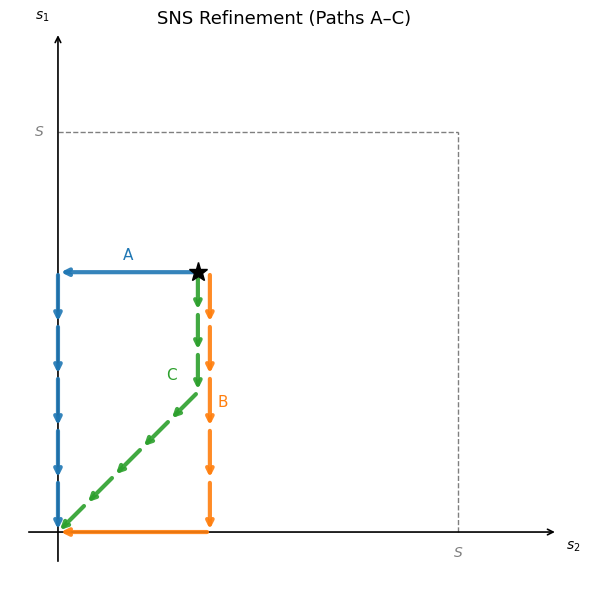

In [144]:
import matplotlib.pyplot as plt

# =========================
# USER CONTROLS
# =========================

LW     = 3
ALPHA  = 0.9
Z      = 5

COLOR_A = '#1f77b4'   # blue
COLOR_B = '#ff7f0e'   # orange
COLOR_C = '#2ca02c'   # green

# =========================


def segmented_arrow(ax, p0, p1, n=4, zorder=None, **arrowprops):
    x0, y0 = p0
    x1, y1 = p1
    for i in range(n):
        xa = x0 + (x1 - x0) * i / n
        ya = y0 + (y1 - y0) * i / n
        xb = x0 + (x1 - x0) * (i + 1) / n
        yb = y0 + (y1 - y0) * (i + 1) / n
        ax.annotate('', xy=(xb, yb), xytext=(xa, ya),
                    arrowprops=arrowprops, zorder=zorder)


# =========================
# FIGURE SETUP
# =========================

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-0.12, 1.25)
ax.set_ylim(-0.12, 1.25)
ax.set_aspect('equal')

for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Axes
ax.annotate('', xy=(1.25, 0), xytext=(-0.08, 0),
            arrowprops=dict(arrowstyle='->', linewidth=1.2, color='black'))
ax.annotate('', xy=(0, 1.25), xytext=(0, -0.08),
            arrowprops=dict(arrowstyle='->', linewidth=1.2, color='black'))

ax.text(1.27, -0.02, r'$s_2$', ha='left', va='top')
ax.text(-0.02, 1.27, r'$s_1$', ha='right', va='bottom')

# Constraints
ax.plot([0, 1], [1, 1], '--', color='black', alpha=0.5, linewidth=1.0)
ax.plot([1, 1], [0, 1], '--', color='black', alpha=0.5, linewidth=1.0)

ax.text(-0.035, 1.0, r'$S$', ha='right', va='center', alpha=0.5)
ax.text(1.0, -0.035, r'$S$', ha='center', va='top', alpha=0.5)

# =========================
# SNS REFINEMENT — PATHS A, B, C
# =========================

# Shared start
xs, ys = 0.35, 0.65
ax.plot(xs, ys, marker='*', markersize=14, color='black', zorder=Z + 3)

# ---------- Path A: left → down ----------
arrow_A = dict(arrowstyle='->', color=COLOR_A, linewidth=LW, alpha=ALPHA)

ax.annotate('', xy=(0.0, ys), xytext=(xs, ys),
            arrowprops=arrow_A, zorder=Z)
segmented_arrow(ax, (0.0, ys), (0.0, 0.0), n=5,
                zorder=Z, **arrow_A)

ax.text(xs * 0.5, ys + 0.03, 'A', color=COLOR_A, fontsize=11, ha='center')

# ---------- Path B: down → left ----------
arrow_B = dict(arrowstyle='->', color=COLOR_B, linewidth=LW, alpha=ALPHA)

xoff = 0.03  # small offset so B is visible distinct from C
segmented_arrow(ax, (xs + xoff, ys), (xs + xoff, 0.0), n=5,
                zorder=Z - 1, **arrow_B)
ax.annotate('', xy=(0.0, 0.0), xytext=(xs + xoff, 0.0),
            arrowprops=arrow_B, zorder=Z - 1)

ax.text(xs + xoff + 0.02, ys * 0.5, 'B', color=COLOR_B, fontsize=11, va='center')

# ---------- Path C: down → diagonal (NO horizontal segments) ----------
arrow_C = dict(arrowstyle='->', color=COLOR_C, linewidth=LW, alpha=ALPHA)

# Step 1: go straight down to the diagonal at (xs, xs)
# (requires ys >= xs, which holds for xs=0.35, ys=0.65)
segmented_arrow(ax, (xs, ys), (xs, xs), n=3,
                zorder=Z + 1, **arrow_C)

# Step 2: follow the diagonal to origin
segmented_arrow(ax, (xs, xs), (0.0, 0.0), n=5,
                zorder=Z + 2, **arrow_C)

ax.text(xs - 0.08, xs + 0.03, 'C', color=COLOR_C, fontsize=11)

# =========================
# TITLE
# =========================

ax.set_title(r'SNS Refinement (Paths A–C)', fontsize=13)

plt.tight_layout()
plt.savefig("SNS_refinement_ABC.png", dpi=300)
plt.show()


In [2]:
import torch
tensor_1 = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/Long_numerical_rollout.p", map_location=torch.device('cpu'))["data"][0:,:30000]/4.44                    
tensor_2 = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ICML26/5_SNS_NS_refinement_clean.p", map_location=torch.device('cpu'))[0:,:30000]
# tensor_3 = torch.load("/scratch/ql2221/thermalizer_data/icml_inferences/debug_run_001/therm_1.pt", map_location=torch.device('cpu'))[:,:30000]
tensor_3 = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ICML26/SNS_NS_refinement_fix_short.p", map_location=torch.device('cpu'))[:,:30000]
tensor_4 = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ICML26/SNS_NS_refinement.p", map_location=torch.device('cpu'))[:,:30000]
tensor_5 = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ICML26/SNS_NS_refinement_down_left.p", map_location=torch.device('cpu'))[:,:30000]
tensor_6 = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ICML26/SNS_NS_refinement_left_down.p", map_location=torch.device('cpu'))[:,:30000]
print(tensor_1.shape)
print(tensor_2.shape)
print(tensor_3.shape)
print(tensor_4.shape)
print(tensor_5.shape)
print(tensor_6.shape)
    
tensor = torch.cat((tensor_1,tensor_2,tensor_3,tensor_4,tensor_5, tensor_6), dim = 0)

/state/partition1/job-1287382/ipykernel_2172018/572786103.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor_1 = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow

torch.Size([5, 30000, 64, 64])
torch.Size([5, 30000, 64, 64])
torch.Size([5, 30000, 64, 64])
torch.Size([5, 30000, 64, 64])
torch.Size([5, 30000, 64, 64])
torch.Size([5, 30000, 64, 64])


In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator

import torch
import thermalizer.kolmogorov.util as util
import cmocean


def plot_rollout_and_ke_spectra_multi(
    X_all,                         # (30, T, 64, 64) = 6 runs * 5 members each
    dt=0.002,
    steps=(0, 3000, 7000, 9000, 10000, 12000),   # time indices to show (top row titles)
    frame_indices=None,                               # optional per-column indices (e.g. 0,5,10,...)
    image_time_mode="steps",                          # "steps" (default) or "custom"
    spectra_time_mode="steps",                        # "steps" (default) or "custom"
    cmap="balance",
    vmin=-4.0,
    vmax=4.0,
    run_labels=("numerical", "clean conditioning", r"fix $s_2$", "Path C", "Path B", "Path A"),
    ylim=(1e1, 1e7),
    xlim=(7e-1, 3.5e1),
    savepath="fig1.png",
    mean_lw=1.2,
    # --- error aggregation options ---
    spectrum_error_mode="relL2",   # "relL2" or "L2"
    spectrum_error_eps=1e-12,      # avoid division-by-zero
):
    """
    Adds aggregate errors (summed over ALL shown snapshots/columns):
      - Spectrum total error vs numerical (run 0), computed on batch-mean KE spectra
      - MSE total error vs numerical (run 0), computed on batch-mean physical fields

    These totals are shown in a narrow text column on the RIGHT of the rollout panels.
    """

    # -------------------------
    # Consistent numpy / torch views
    # -------------------------
    def as_torch_and_numpy(X):
        if torch.is_tensor(X):
            Xt = X.detach().cpu()
            Xn = Xt.numpy()
        else:
            Xn = np.asarray(X)
            Xt = torch.from_numpy(Xn).to(dtype=torch.float32, device="cpu")
        return Xt, Xn

    X_t, X_n = as_torch_and_numpy(X_all)

    assert X_n.ndim == 4 and X_n.shape[0] == 30 and X_n.shape[2:] == (64, 64), \
        f"Expected X_all shape (30, T, 64, 64), got {tuple(X_n.shape)}"

    T = X_n.shape[1]

    # columns are defined by `steps`
    steps = tuple(int(s) for s in steps if 0 <= int(s) < T)
    ncols = len(steps)
    label_fs = 10

    # optional custom per-column indices
    if frame_indices is None:
        frame_indices = steps
    else:
        frame_indices = tuple(int(i) for i in frame_indices)
        if len(frame_indices) != ncols:
            raise ValueError(
                f"frame_indices must have same length as steps. "
                f"Got len(frame_indices)={len(frame_indices)} vs len(steps)={ncols}."
            )
        for i in frame_indices:
            if not (0 <= i < T):
                raise ValueError(f"frame_indices contains out-of-range index {i} (T={T}).")

    def pick_time(mode, col):
        if mode == "steps":
            return steps[col]
        elif mode == "custom":
            return frame_indices[col]
        else:
            raise ValueError("mode must be 'steps' or 'custom'.")

    # -------------------------
    # Grouping: 6 runs * 5 members each
    # -------------------------
    n_runs = 6
    members_per_run = 5
    if len(run_labels) != n_runs:
        raise ValueError(f"run_labels must have length {n_runs} (got {len(run_labels)}).")

    runs_n = [X_n[r * members_per_run:(r + 1) * members_per_run] for r in range(n_runs)]
    runs_t = [X_t[r * members_per_run:(r + 1) * members_per_run] for r in range(n_runs)]
    run0_n = [g[0] for g in runs_n]  # (T, 64, 64) first member per run

    cmap_obj = getattr(cmocean.cm, cmap)

    # -------------------------
    # Error computation helpers
    # -------------------------
    grid = util.fourierGrid(64)

    def to_numpy(a):
        return a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a)

    def batch_spectrum(group_torch, step_idx):
        batch = group_torch[:, step_idx].float()  # (5, 64, 64)
        k, E = util.get_ke_batch(batch, grid)     # (K,), (5, K)
        return to_numpy(k), to_numpy(E)           # E is (5, K)

    def spectrum_err(E_mean, E0_mean, mode="relL2", eps=1e-12):
        # both are (K,)
        diff2 = np.sum((E_mean - E0_mean) ** 2)
        if mode == "L2":
            return np.sqrt(diff2)
        elif mode == "relL2":
            denom = np.sum(E0_mean ** 2) + eps
            return np.sqrt(diff2 / denom)
        else:
            raise ValueError("spectrum_error_mode must be 'relL2' or 'L2'.")

    def mse_err(X_mean, X0_mean):
        # both (64,64)
        return float(np.mean((X_mean - X0_mean) ** 2))

    # -------------------------
    # Precompute per-snapshot spectra + batch means, then totals
    # -------------------------
    # spectra[(r, col)] = (k, E) where E is (5,K)
    spectra = {}
    # field_means[(r, col)] = (64,64) mean over 5 members
    field_means = {}

    for col in range(ncols):
        spec_t = pick_time(spectra_time_mode, col)
        img_t = pick_time(image_time_mode, col)

        for r in range(n_runs):
            # spectra at spec_t
            spectra[(r, col)] = batch_spectrum(runs_t[r], spec_t)

            # batch mean field at img_t (for MSE aggregation)
            bm = runs_t[r][:, img_t].float().mean(dim=0)  # (64,64)
            field_means[(r, col)] = to_numpy(bm)

    # totals summed over snapshots/columns, relative to run 0 ("numerical")
    total_spec_err = np.zeros(n_runs, dtype=float)
    total_mse = np.zeros(n_runs, dtype=float)

    for col in range(ncols):
        # spectrum baseline (batch mean)
        k0, E0 = spectra[(0, col)]
        E0m = E0.mean(axis=0)  # (K,)

        # mse baseline (batch mean field)
        X0m = field_means[(0, col)]  # (64,64)

        for r in range(n_runs):
            k, E = spectra[(r, col)]
            Em = E.mean(axis=0)
            total_spec_err[r] += spectrum_err(
                Em, E0m, mode=spectrum_error_mode, eps=spectrum_error_eps
            )

            Xm = field_means[(r, col)]
            total_mse[r] += mse_err(Xm, X0m)

    # -------------------------
    # Figure / gridspec (extra right column for text)
    # -------------------------
    text_col_width = 0.55  # relative to one normal column
    fig = plt.figure(figsize=(1.25 * ncols + text_col_width, 12.0))

    # +1 column for the text on the right
    gs = fig.add_gridspec(
        n_runs + 1,
        ncols + 1,
        height_ratios=[1] * n_runs + [0.8],
        width_ratios=[1] * ncols + [text_col_width],
        hspace=0.015,
        wspace=0.02,
    )

    fig.subplots_adjust(
        left=0.05, right=0.995,
        top=0.94, bottom=0.055,
        wspace=0.02,
    )

    # -------------------------
    # Rollout panels
    # -------------------------
    for col, _ in enumerate(steps):
        shown_t = pick_time(image_time_mode, col)

        axs = [fig.add_subplot(gs[r, col]) for r in range(n_runs)]

        for r in range(n_runs):
            axs[r].imshow(
                run0_n[r][shown_t],
                cmap=cmap_obj,
                vmin=vmin,
                vmax=vmax,
                origin="lower",
                aspect="equal",
            )
            axs[r].set_xticks([])
            axs[r].set_yticks([])

        # title reflects the actual time index used for the images
        t_seconds = shown_t * dt
        axs[0].set_title(
            f"t = {t_seconds:.0f}s\nstep = {shown_t}",
            fontsize=label_fs,
            pad=0.5,
        )

        if col == 0:
            for ax, lab in zip(axs, run_labels):
                ax.set_ylabel(lab, fontsize=label_fs)

    # -------------------------
    # Right-side text column: totals (sum over all shown snapshots)
    # -------------------------
    for r in range(n_runs):
        ax_txt = fig.add_subplot(gs[r, ncols])
        ax_txt.axis("off")

        # For run 0, errors are identically zero by construction; show anyway
        ax_txt.text(
            0.0, 0.5,
            "Σ spec err\n"
            f"{total_spec_err[r]:.3e}\n\n"
            "Σ MSE\n"
            f"{total_mse[r]:.3e}",
            va="center", ha="left",
            fontsize=9,
        )

    # blank cell on bottom-right (spectra row, text column)
    ax_blank = fig.add_subplot(gs[n_runs, ncols])
    ax_blank.axis("off")

    # -------------------------
    # KE spectra (batch mean only)
    # -------------------------
    def plot_batch_mean(ax, k, E, lw, label):
        ax.loglog(k, E.mean(axis=0), lw=lw, label=label)

    spec_axes = []
    for col in range(ncols):
        ax = fig.add_subplot(
            gs[n_runs, col],
            sharex=spec_axes[0] if spec_axes else None,
            sharey=spec_axes[0] if spec_axes else None,
        )
        spec_axes.append(ax)

        for r in range(n_runs):
            k, E = spectra[(r, col)]
            plot_batch_mean(ax, k, E, lw=mean_lw, label=run_labels[r])

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        ax.set_xlabel("k", fontsize=label_fs)
        ax.xaxis.set_label_coords(0.5, -0.10)

        if col == 0:
            ax.set_ylabel("KE spectrum", fontsize=label_fs)

        ax.yaxis.set_major_locator(FixedLocator([1e1, 1e7]))
        ax.yaxis.set_major_formatter(FixedFormatter([r"$10^1$", r"$10^7$"]))
        ax.yaxis.set_minor_locator(NullLocator())

        ax.xaxis.set_major_locator(NullLocator())
        ax.xaxis.set_minor_locator(NullLocator())
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

        ax.tick_params(axis="y", length=3, width=0.6, labelsize=label_fs)
        if col != 0:
            ax.tick_params(labelleft=False)

        if col == 0:
            ax.legend(
                loc="lower left",
                frameon=False,
                fontsize=7,
                handlelength=1.2,
                handletextpad=0.4,
                borderpad=0.1,
                labelspacing=0.25,
            )

    fig.suptitle("Kolmogorov Flow (6 runs × 5 members)", fontsize=12, y=0.985)

    # IMPORTANT: bbox_inches="tight" can re-introduce padding; omit it
    plt.savefig(savepath, dpi=300)
    plt.show()


In [56]:
plot_rollout_and_ke_spectra_multi(
    ,
    dt=0.002,
    steps=None,     # <-- IMPORTANT
    n_frames=10,    # <-- this controls the number of frames
    savepath="fig1_10frames.png",
)


AssertionError: Expected X_all shape (30, T, 64, 64), got (20, 30000, 64, 64)

In [2]:
import torch
tensor_1 = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/Long_numerical_rollout.p", map_location=torch.device('cpu'),weights_only = True)["data"][0:5,:30000]/4.44                    
tensor_2 = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ICML26/FINAL_PAPER_EMU.p", map_location=torch.device('cpu'),weights_only = True)[0:5,:30000]
tensor_3 = torch.load("/scratch/ql2221/thermalizer_data/icml_inferences/debug_run_001/therm_1.pt", map_location=torch.device('cpu'),weights_only = True)[:5,:30000]
tensor_4 = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ICML26/FINAL_PAPER_movie.p", map_location=torch.device('cpu'),weights_only = True)[-5:,:30000]
tensor_5 = torch.load("/scratch/ql2221/PDE_data/Kolmogorov_flow/Reynolds10k/ACDM200_ICML.p", map_location=torch.device('cpu'),weights_only = True)

In [3]:
tensor = torch.cat((tensor_1,tensor_2, tensor_3, tensor_4), dim = 0)
print(tensor.shape)

torch.Size([20, 30000, 64, 64])


In [8]:
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


def split_methods(tensor, n_methods=4, n_runs_per_method=5):
    method_names = ["GT", "Gaussian", "Thermalization", "My method"]
    out = {}
    for m in range(n_methods):
        a = m * n_runs_per_method
        b = (m + 1) * n_runs_per_method
        out[method_names[m]] = tensor[a:b]
    return out


def radial_bin_setup(H, W, device=None):
    y = torch.arange(H, device=device) - H // 2
    x = torch.arange(W, device=device) - W // 2
    yy, xx = torch.meshgrid(y, x, indexing="ij")
    rr = torch.sqrt(xx.float() ** 2 + yy.float() ** 2)

    rbin = torch.floor(rr).long()
    max_r = int(rbin.max().item())
    counts = torch.bincount(rbin.flatten(), minlength=max_r + 1).float()
    radii = torch.arange(max_r + 1, device=device).float()
    return rbin, counts, radii


def radial_average_2d(field2d, rbin, counts):
    vals = torch.bincount(
        rbin.flatten(),
        weights=field2d.flatten(),
        minlength=counts.numel()
    )
    return vals / counts.clamp_min(1.0)


@torch.no_grad()
def spatiotemporal_corr_radial_slice(
    x,
    t_start,
    t_end,
    max_tau=100,
    r_max=None,
    subtract_mean=True,
    normalize=True,
    device=None,
    show_progress=True,
    method_name="method",
):
    """
    x: [Nrun, T, H, W]
    Use only x[:, t_start:t_end].
    Returns:
        C_rt: [max_tau+1, Nr_kept]
        radii: [Nr_kept]
        taus: [max_tau+1]
    """
    assert x.ndim == 4
    Nrun, T, H, W = x.shape

    if device is None:
        device = x.device

    x = x.to(device=device, dtype=torch.float32)

    t_start = max(0, t_start)
    t_end = min(T, t_end)
    assert t_end > t_start, "Need t_end > t_start"

    x = x[:, t_start:t_end]   # [Nrun, Tsel, H, W]
    Tsel = x.shape[1]

    if max_tau >= Tsel:
        max_tau = Tsel - 1

    if subtract_mean:
        mu = x.mean(dim=(1, 2, 3), keepdim=True)
        x = x - mu

    if normalize:
        var = (x ** 2).mean()
    else:
        var = torch.tensor(1.0, device=device)

    Xf = torch.fft.fft2(x, dim=(-2, -1))

    rbin, counts, radii = radial_bin_setup(H, W, device=device)

    if r_max is None:
        keep = torch.ones_like(radii, dtype=torch.bool)
    else:
        keep = radii <= r_max

    radii_kept = radii[keep]
    C_rt = torch.empty((max_tau + 1, radii_kept.numel()), device=device)

    tau_iter = range(max_tau + 1)
    if show_progress:
        tau_iter = tqdm(tau_iter, desc=f"{method_name}: tau loop", leave=True)

    for tau in tau_iter:
        cross_spec = (Xf[:, :Tsel - tau] * torch.conj(Xf[:, tau:])).mean(dim=(0, 1))
        corr_xy = torch.fft.ifft2(cross_spec).real
        corr_xy = corr_xy / (H * W)
        corr_xy = torch.fft.fftshift(corr_xy, dim=(-2, -1))
        corr_xy = corr_xy / var.clamp_min(1e-12)

        radial = radial_average_2d(corr_xy, rbin, counts)
        C_rt[tau] = radial[keep]

    taus = torch.arange(max_tau + 1, device=device)
    return C_rt.cpu(), radii_kept.cpu(), taus.cpu()


def plot_spatiotemporal_correlation_heatmaps_slice(
    tensor,
    t_start=15000,
    t_end=16000,
    max_tau=100,
    r_max=10,
    cmap="viridis",
    vmin=None,
    vmax=None,
    device=None,
    show_progress=True,
):
    methods = split_methods(tensor)
    results = {}

    items = methods.items()
    if show_progress:
        items = tqdm(list(items), desc="Methods", leave=True)

    for name, x in items:
        C_rt, radii, taus = spatiotemporal_corr_radial_slice(
            x,
            t_start=t_start,
            t_end=t_end,
            max_tau=max_tau,
            r_max=r_max,
            subtract_mean=True,
            normalize=True,
            device=device,
            show_progress=show_progress,
            method_name=name,
        )
        results[name] = (C_rt, radii, taus)

    if vmin is None:
        vmin = min(v[0].min().item() for v in results.values())
    if vmax is None:
        vmax = max(v[0].max().item() for v in results.values())

    fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)
    axes = axes.ravel()

    for ax, (name, (C_rt, radii, taus)) in zip(axes, results.items()):
        im = ax.imshow(
            C_rt.numpy(),
            origin="lower",
            aspect="auto",
            extent=[radii[0].item(), radii[-1].item(), taus[0].item(), taus[-1].item()],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(name)
        ax.set_xlabel("r")
        ax.set_ylabel("tau")

    cbar = fig.colorbar(im, ax=axes, shrink=0.95)
    cbar.set_label("C(r, tau)")
    plt.show()

    return results

Methods: 100%|██████████| 4/4 [00:18<00:00,  4.74s/it]


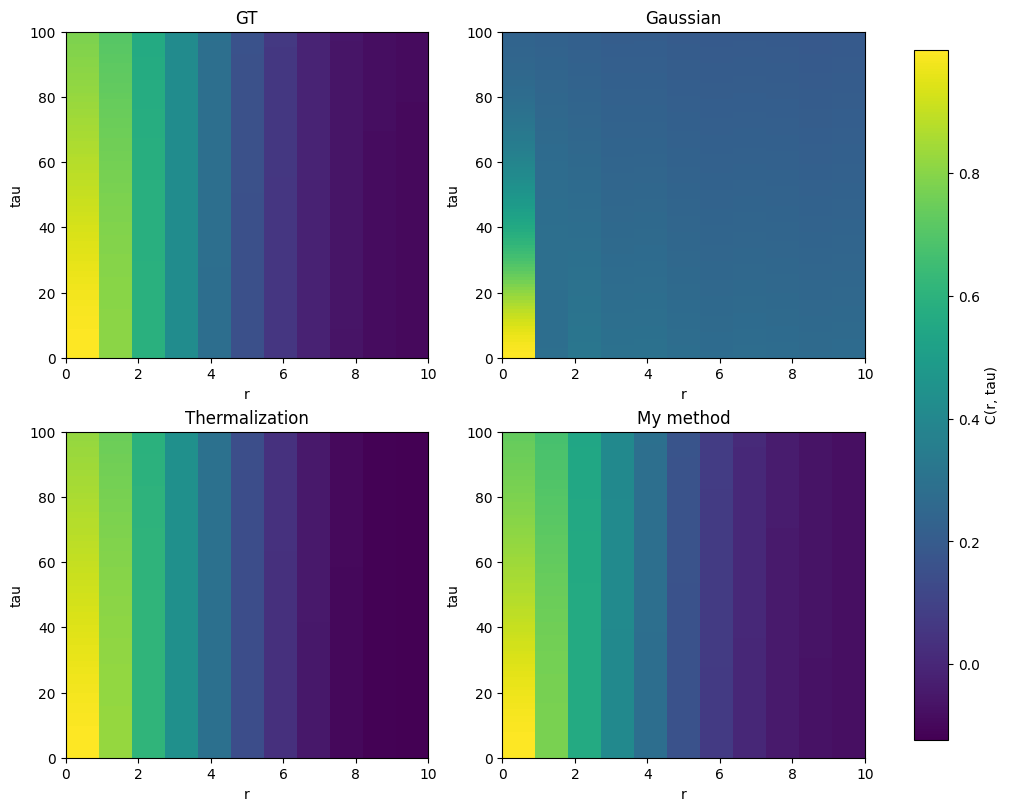

In [9]:
results_zoom = plot_spatiotemporal_correlation_heatmaps_slice(
    tensor,
    t_start=15000,
    t_end=16000,
    max_tau=100,
    r_max=10,
    device="cpu",   # or "cuda"
    show_progress=True,
)

In [6]:
import numpy as np
import matplotlib
matplotlib.use("Agg")  # headless / non-interactive backend
import matplotlib.pyplot as plt

from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator
from matplotlib.transforms import Bbox

from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
from tqdm import tqdm

import torch
import thermalizer.kolmogorov.util as util
import cmocean


def make_movie_snapshot_5traj(
    X_long,                              # (20, T, 64, 64)
    save_path="snapshot_5traj_movie.mp4",
    dt=0.002,
    fps=30,
    stride=10,
    steps=None,
    traj_ids=(0, 1, 2, 3, 4),
    cmap="balance",
    vmin=-4.0,
    vmax=4.0,

    # labels / typography
    row_labels=("Numerical solver", "Gaussian", "Thermalizer", "SNS refined"),
    spec_label="KE spectrum",
    label_fs=10,
    suptitle_y=0.97,
    top_margin=0.90,                     # reserve space for suptitle (like your reference code)
    title_pad=2.0,                       # in points; larger than 0.25 so titles breathe

    # spectra axes
    ylim=(1e1, 1e7),
    xlim=(7e-1, 3.5e1),
    mean_lw=1.2,
    line_alpha=0.65,
    spec_ytick_fs=None,

    # layout like the reference code
    fig_w=2.6,                           # width per column (inches)
    fig_h_row=2.1,                       # height per row (inches)
    hspace=0.15,
    wspace=0.10,

    # shared colorbar (external)
    cbar_width=0.010,
    cbar_pad=0.010,

    # movie writer
    bitrate="20000k",
    dpi=150,
    interpolation="nearest",
    origin="lower",
):
    """
    Re-formatted layout (5 rows x 5 cols):
      - Rows 0..3: images (Numerical / Gaussian / Thermalizer / SNS refined)
      - Row 4: spectra (one axis per trajectory)
    Spacing/geometry mirrors your "nice" reference code:
      - gs with hspace/wspace
      - ax.set_box_aspect(1)
      - top margin reserved for suptitle
      - external colorbar so the grid isn't squeezed
    """

    # ---------- helpers ----------
    def ensure_even_hw(rgb: np.ndarray) -> np.ndarray:
        h, w = rgb.shape[:2]
        pad_h = h % 2
        pad_w = w % 2
        if pad_h == 0 and pad_w == 0:
            return rgb
        return np.pad(rgb, ((0, pad_h), (0, pad_w), (0, 0)), mode="edge")

    def to_numpy(a):
        return a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a)

    # ---------- convert input ----------
    if hasattr(X_long, "detach"):
        Xl_t = X_long.detach().cpu().to(dtype=torch.float32)
        Xl_n = Xl_t.numpy()
    else:
        Xl_n = np.asarray(X_long)
        Xl_t = torch.from_numpy(Xl_n).to(dtype=torch.float32, device="cpu")

    if Xl_n.ndim != 4 or Xl_n.shape[0] != 20 or Xl_n.shape[2:] != (64, 64):
        raise ValueError(f"Expected X_long shape (20, T, 64, 64), got {tuple(Xl_n.shape)}")

    T = Xl_n.shape[1]

    traj_ids = tuple(int(i) for i in traj_ids)
    if len(traj_ids) != 5:
        raise ValueError(f"`traj_ids` must have length 5, got {len(traj_ids)}")
    if any((i < 0 or i > 4) for i in traj_ids):
        raise ValueError("Each trajectory id must be in {0,1,2,3,4}.")

    # frame indices
    if steps is None:
        stride = max(1, int(stride))
        frame_indices = list(range(0, T, stride))
        if frame_indices[-1] != T - 1:
            frame_indices.append(T - 1)
    else:
        frame_indices = [int(s) for s in steps if 0 <= int(s) < T]
        if not frame_indices:
            raise ValueError("`steps` produced no valid indices in [0, T-1].")
        if frame_indices[-1] != T - 1:
            frame_indices.append(T - 1)

    # groups
    num_n, gau_n, thm_n, sns_n = Xl_n[0:5], Xl_n[5:10], Xl_n[10:15], Xl_n[15:20]
    num_t, gau_t, thm_t, sns_t = Xl_t[0:5], Xl_t[5:10], Xl_t[10:15], Xl_t[15:20]

    # spectra machinery
    grid = util.fourierGrid(64)

    def single_traj_spectrum(group_torch, traj_idx, step_idx):
        batch = group_torch[traj_idx:traj_idx + 1, step_idx].float()
        k, E = util.get_ke_batch(batch, grid)  # E: (1,Nk)
        return to_numpy(k), to_numpy(E)[0]

    colors = {"num": "red", "gau": "gray", "thm": "orange", "sns": "blue"}
    labels = {"num": "Numerical", "gau": "Gaussian", "thm": "Thermalizer", "sns": "SNS refined"}

    if spec_ytick_fs is None:
        spec_ytick_fs = max(1, label_fs - 2)

    cmap_obj = getattr(cmocean.cm, cmap)

    # ---------- figure / gridspec (single block like reference) ----------
    ncols = 5
    n_image_rows = 4
    nrows_total = n_image_rows + 1  # + spectra row

    fig = plt.figure(figsize=(fig_w * ncols + 1.0, fig_h_row * nrows_total), dpi=dpi)
    gs = fig.add_gridspec(nrows_total, ncols, hspace=hspace, wspace=wspace)

    # reserve space for suptitle
    fig.subplots_adjust(top=top_margin)

    # suptitle
    suptitle = fig.suptitle("", fontsize=label_fs + 2, y=suptitle_y)

    f0 = frame_indices[0]

    # images
    ims_img = [[None] * ncols for _ in range(n_image_rows)]
    img_axes = [[None] * ncols for _ in range(n_image_rows)]
    lastcol_img_axes = []  # for colorbar geometry

    for r in range(n_image_rows):
        for c, tid in enumerate(traj_ids):
            ax = fig.add_subplot(gs[r, c])
            img_axes[r][c] = ax

            if r == 0:
                data0 = num_n[tid, f0]
            elif r == 1:
                data0 = gau_n[tid, f0]
            elif r == 2:
                data0 = thm_n[tid, f0]
            else:
                data0 = sns_n[tid, f0]

            im = ax.imshow(
                data0,
                cmap=cmap_obj,
                vmin=vmin,
                vmax=vmax,
                interpolation=interpolation,
                origin=origin,
            )
            ims_img[r][c] = im

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_box_aspect(1)

            # titles only on top row
            if r == 0:
                ax.set_title(f"Trajecotry {tid}", fontsize=label_fs, pad=title_pad)
            else:
                ax.set_title("")

            # row labels on first column (like reference)
            if c == 0:
                ax.set_ylabel(row_labels[r], fontsize=label_fs)

            if c == ncols - 1:
                lastcol_img_axes.append((ax, im))

    # shared external colorbar spanning the full image block
    fig.canvas.draw()
    img_bbox = Bbox.union([img_axes[r][c].get_position() for r in range(n_image_rows) for c in range(ncols)])
    cax = fig.add_axes([img_bbox.x1 + cbar_pad, img_bbox.y0, cbar_width, img_bbox.height])
    cb = fig.colorbar(ims_img[0][0], cax=cax)
    cb.outline.set_visible(False)
    cb.set_ticks([vmin, 0.0, vmax])
    cb.set_ticklabels([f"{vmin:g}", "0", f"{vmax:g}"])
    cb.ax.tick_params(labelsize=label_fs - 1, length=2, width=0.6)

    # spectra row
    spec_axes = []
    spec_lines = []
    for c, tid in enumerate(traj_ids):
        ax = fig.add_subplot(gs[n_image_rows, c], sharex=spec_axes[0] if spec_axes else None,
                             sharey=spec_axes[0] if spec_axes else None)
        spec_axes.append(ax)
        ax.set_box_aspect(1)  # optional, but matches the aesthetic of the reference code

        line_dict = {}
        for key, group in (("num", num_t), ("gau", gau_t), ("thm", thm_t), ("sns", sns_t)):
            k, E = single_traj_spectrum(group, tid, f0)
            (ln,) = ax.loglog(k, E, color=colors[key], lw=mean_lw, alpha=line_alpha, label=labels[key])
            line_dict[key] = ln
        spec_lines.append(line_dict)

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        # label style similar to your original
        if c == 0:
            ax.set_ylabel(spec_label, fontsize=label_fs)
        ax.set_xlabel("k", fontsize=label_fs)

        ax.yaxis.set_major_locator(FixedLocator([1e1, 1e7]))
        ax.yaxis.set_major_formatter(FixedFormatter([r"$10^1$", r"$10^7$"]))
        ax.yaxis.set_minor_locator(NullLocator())
        ax.tick_params(axis="y", length=3, width=0.6, labelsize=spec_ytick_fs)
        if c != 0:
            ax.tick_params(labelleft=False)

        if c == ncols - 1:
            ax.legend(loc="lower right", frameon=False, fontsize=8)

    fig.canvas.draw()

    # ---------- render helpers ----------
    def fig_to_rgb_even():
        fig.canvas.draw()
        buf = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
        return ensure_even_hw(buf.copy())

    def update(i):
        f = frame_indices[i]
        suptitle.set_text(f"t = {f*dt:.3f}   (step = {f})")

        # images
        for c, tid in enumerate(traj_ids):
            ims_img[0][c].set_data(num_n[tid, f])
            ims_img[1][c].set_data(gau_n[tid, f])
            ims_img[2][c].set_data(thm_n[tid, f])
            ims_img[3][c].set_data(sns_n[tid, f])

        # spectra
        for c, tid in enumerate(traj_ids):
            for key, group in (("num", num_t), ("gau", gau_t), ("thm", thm_t), ("sns", sns_t)):
                k, E = single_traj_spectrum(group, tid, f)
                spec_lines[c][key].set_data(k, E)

    # ---------- writer ----------
    first_frame = fig_to_rgb_even()
    h, w = first_frame.shape[:2]

    writer = FFMPEG_VideoWriter(
        filename=save_path,
        size=(w, h),
        fps=fps,
        codec="libx264",
        bitrate=bitrate,
        preset="medium",
        ffmpeg_params=["-pix_fmt", "yuv420p"],
    )

    try:
        for i in tqdm(range(len(frame_indices)), desc="Rendering movie"):
            update(i)
            writer.write_frame(fig_to_rgb_even())
    finally:
        writer.close()
        plt.close(fig)

    print(f"Movie saved: {save_path}")
    return save_path

In [7]:
# X_long: shape (20, T, 64, 64)  (torch.Tensor or np.ndarray)

out = make_movie_snapshot_5traj(
    tensor,
    save_path="SNS_Kolmogorov.mp4",
    dt=0.002,
    fps=20,
    stride=5,                 # or steps=[0, 10, 20, ...]
    traj_ids=(0, 1, 2, 3, 4),
    vmin=-4.0,
    vmax=4.0,

    # spacing knobs (most useful)
    hspace=0.20,
    wspace=0.12,
    top_margin=0.92,
)
print(out)

/ext3/miniforge3/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
Rendering movie: 100%|██████████| 6001/6001 [42:00<00:00,  2.38it/s]


Movie saved: SNS_Kolmogorov.mp4
SNS_Kolmogorov.mp4


In [ ]:
import numpy as np
import torch
import thermalizer.kolmogorov.util as util


def spectral_mse_last_steps(
    X_long,              # (20, T, 64, 64) torch or numpy
    last_steps=10_000,
    eps=0.0,             # set >0 if you want to MSE in log-space safely (see note below)
):
    """
    Computes the average KE power spectrum over the last `last_steps` time steps,
    then averages over the 5 trajectories for each method, and reports spectral MSE
    vs the numerical solver spectrum.

    Methods in X_long are assumed grouped as:
      0:5   numerical
      5:10  gaussian
      10:15 thermalizer
      15:20 sns refined
    """

    # ---- to torch (cpu, float32) ----
    if torch.is_tensor(X_long):
        X = X_long.detach().cpu().to(dtype=torch.float32)
    else:
        X = torch.from_numpy(np.asarray(X_long)).to(dtype=torch.float32, device="cpu")

    if X.ndim != 4 or X.shape[0] != 20 or tuple(X.shape[2:]) != (64, 64):
        raise ValueError(f"Expected X_long shape (20, T, 64, 64), got {tuple(X.shape)}")

    T = X.shape[1]
    n_last = int(min(max(1, last_steps), T))
    start = T - n_last  # inclusive

    # ---- split methods: each is (5, T, 64, 64) ----
    groups = {
        "num": X[0:5],
        "gau": X[5:10],
        "thm": X[10:15],
        "sns": X[15:20],
    }

    # ---- spectrum helper ----
    grid = util.fourierGrid(64)

    def avg_spectrum_last(group_5T):
        """
        group_5T: (5, T, 64, 64)
        returns: (k, E_mean) where E_mean is averaged over (traj,time) in last window
        """
        # take last window: (5, n_last, 64, 64)
        window = group_5T[:, start:, :, :].contiguous()

        # batch all traj/time together: (5*n_last, 64, 64)
        batch = window.view(-1, 64, 64)

        # util.get_ke_batch returns (k, E_batch) with E_batch shape (B, Nk)
        k, E_batch = util.get_ke_batch(batch, grid)

        # average over batch dimension -> (Nk,)
        E_mean = E_batch.mean(dim=0)

        return k, E_mean

    # ---- compute mean spectra ----
    k_num, E_num = avg_spectrum_last(groups["num"])
    spectra = {"num": E_num}

    for key in ("gau", "thm", "sns"):
        k_m, E_m = avg_spectrum_last(groups[key])

        # sanity check: k grids should match
        if k_m.shape != k_num.shape or not torch.allclose(k_m, k_num, rtol=1e-5, atol=1e-8):
            raise RuntimeError(f"k-grid mismatch between numerical and {key} spectra.")
        spectra[key] = E_m

    # ---- spectral MSE vs numerical ----
    def mse(a, b):
        return torch.mean((a - b) ** 2).item()

    # Optionally do log-space MSE: mse(log(E+eps), log(E_num+eps))
    # Set eps e.g. 1e-12 if you want this (common when spectra span many decades).
    if eps > 0.0:
        Eref = torch.log(spectra["num"] + eps)
        mses = {
            key: torch.mean((torch.log(spectra[key] + eps) - Eref) ** 2).item()
            for key in ("gau", "thm", "sns")
        }
        print(f"Log-spectral MSE over last {n_last} steps (avg over 5 traj) vs Numerical:")
    else:
        mses = {key: mse(spectra[key], spectra["num"]) for key in ("gau", "thm", "sns")}
        print(f"Spectral MSE over last {n_last} steps (avg over 5 traj) vs Numerical:")

    for key in ("gau", "thm", "sns"):
        name = {"gau": "Gaussian", "thm": "Thermalizer", "sns": "SNS refined"}[key]
        print(f"  {name:12s}: {mses[key]:.6e}")

    return {
        "k": k_num.detach().cpu().numpy(),
        "E_num": spectra["num"].detach().cpu().numpy(),
        "E_gau": spectra["gau"].detach().cpu().numpy(),
        "E_thm": spectra["thm"].detach().cpu().numpy(),
        "E_sns": spectra["sns"].detach().cpu().numpy(),
        "mse": mses,
        "n_last": n_last,
    }


# Example:
out = spectral_mse_last_steps(tensor, last_steps=10_000)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator
from matplotlib.transforms import Bbox

import torch
import thermalizer.kolmogorov.util as util
import cmocean


def plot_snapshot_5traj_and_ke_spectra(
    X_long,                      # (20, T, 64, 64)
    dt=0.002,
    step=None,                   # snapshot time index; if None -> last frame
    traj_ids=(0, 1, 2, 3, 4),     # which 5 trajectories to show as columns
    cmap="balance",
    vmin=-4.0,
    vmax=4.0,
    row_labels=("Numerical solver", "Gaussian", "Thermalizer", "SNS refined"),
    ylim=(1e1, 1e7),
    xlim=(7e-1, 3.5e1),
    savepath="fig1.png",
    mean_lw=1.2,
    # sizing / spacing controls
    fig_w_per_col=1.25,
    fig_h=None,
    row_gap_cm=0.1,
    spectra_height_in=1.15,
    # control gaps
    hspace_images=0.0,
    hspace_blocks=0.02,
    wspace=0.02,
    left=0.05,
    right=0.965,                 # leave room for colorbar on the far right
    top=0.94,
    bottom=0.065,
    label_fs=10,
    spectra_block_ratio=0.42,    # used only if fig_h is forced
    title_pad=0.25,
    # spectra styling
    line_alpha=0.65,
    # spectra typography
    spec_ytick_fs=None,          # if None -> label_fs-2
    # colorbar geometry
    cbar_gap=0.008,
    cbar_w=0.016,
):
    """
    Shows a SINGLE snapshot time (step) across 5 trajectories (columns).

    Rows:
      1) Numerical solver
      2) Gaussian
      3) Thermalizer
      4) SNS refined
      5) KE spectrum (for that trajectory at that step)

    X_long: (20, T, 64, 64) arranged as:
             0:5   Numerical
             5:10  Gaussian approximation
             10:15 Thermalizer
             15:20 SNS refined
    """

    # -------------------------
    # Conversions
    # -------------------------
    def as_torch_and_numpy(X):
        if torch.is_tensor(X):
            Xt = X.detach().cpu()
            Xn = Xt.numpy()
        else:
            Xn = np.asarray(X)
            Xt = torch.from_numpy(Xn).to(dtype=torch.float32, device="cpu")
        return Xt, Xn

    def to_numpy(a):
        return a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a)

    Xl_t, Xl_n = as_torch_and_numpy(X_long)

    assert Xl_n.ndim == 4 and Xl_n.shape[0] == 20 and Xl_n.shape[2:] == (64, 64), \
        f"Expected X_long shape (20, T, 64, 64), got {tuple(Xl_n.shape)}"

    T_long = Xl_n.shape[1]
    if step is None:
        step = T_long - 1
    step = int(step)
    if not (0 <= step < T_long):
        raise ValueError(f"`step` must be in [0, {T_long-1}], got {step}")

    traj_ids = tuple(int(i) for i in traj_ids)
    if len(traj_ids) != 5:
        raise ValueError(f"`traj_ids` must have length 5, got {len(traj_ids)}")
    if any((i < 0 or i > 4) for i in traj_ids):
        raise ValueError("Each trajectory id must be in {0,1,2,3,4} (since groups are size 5).")

    ncols = 5

    # -------------------------
    # Slice groups (5 each)
    # -------------------------
    num_n, gau_n, thm_n, sns_n = (
        Xl_n[0:5],
        Xl_n[5:10],
        Xl_n[10:15],
        Xl_n[15:20],
    )
    num_t, gau_t, thm_t, sns_t = (
        Xl_t[0:5],
        Xl_t[5:10],
        Xl_t[10:15],
        Xl_t[15:20],
    )

    cmap_obj = getattr(cmocean.cm, cmap)

    # -------------------------
    # Physical sizing (4 rollout rows now)
    # -------------------------
    row_gap_in = row_gap_cm / 2.54
    img_block_h_in = 4.0 * fig_w_per_col + 3.0 * row_gap_in  # 4 rows -> 3 gaps

    if fig_h is None:
        fig_h = img_block_h_in + spectra_height_in
        spec_block_h_in = spectra_height_in
    else:
        spec_block_h_in = None

    # -------------------------
    # Figure layout: 2 blocks (images + spectra)
    # -------------------------
    fig = plt.figure(figsize=(fig_w_per_col * ncols, fig_h))

    if spec_block_h_in is not None:
        outer = fig.add_gridspec(
            2, 1,
            height_ratios=[img_block_h_in, spec_block_h_in],
            hspace=hspace_blocks
        )
    else:
        outer = fig.add_gridspec(
            2, 1,
            height_ratios=[4.0, spectra_block_ratio],
            hspace=hspace_blocks
        )

    fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom)
    fig.suptitle(
            f"t = {step*dt:.3f}s   (step = {step})",
            fontsize=label_fs + 1,
            y=1
        )

    gs_img = outer[0].subgridspec(4, ncols, hspace=hspace_images, wspace=wspace)
    gs_spec = outer[1].subgridspec(1, ncols, hspace=0.0, wspace=wspace)

    # Store one mappable for the colorbar + all image axes (to compute bbox)
    im_for_cbar = None
    img_axes_all = []

    # -------------------------
    # Rollout snapshot panels (columns = trajectories)
    # -------------------------
    for col, tid in enumerate(traj_ids):
        axs = [fig.add_subplot(gs_img[r, col]) for r in range(4)]
        img_axes_all.extend(axs)

        if col == 0:
            im_for_cbar = axs[0].imshow(
                num_n[tid, step], cmap=cmap_obj, vmin=vmin, vmax=vmax,
                origin="lower", aspect="equal"
            )
        else:
            axs[0].imshow(num_n[tid, step], cmap=cmap_obj, vmin=vmin, vmax=vmax,
                          origin="lower", aspect="equal")

        axs[1].imshow(gau_n[tid, step], cmap=cmap_obj, vmin=vmin, vmax=vmax,
                      origin="lower", aspect="equal")
        axs[2].imshow(thm_n[tid, step], cmap=cmap_obj, vmin=vmin, vmax=vmax,
                      origin="lower", aspect="equal")
        axs[3].imshow(sns_n[tid, step], cmap=cmap_obj, vmin=vmin, vmax=vmax,
                      origin="lower", aspect="equal")

        for ax in axs:
            ax.set_xticks([])
            ax.set_yticks([])

        axs[0].set_title(
            f"traj = {tid}",
            fontsize=label_fs,
            pad=title_pad,
        )

        if col == 0:
            for ax, lab in zip(axs, row_labels):
                ax.set_ylabel(lab, fontsize=label_fs, labelpad=2)

    # -------------------------
    # Shared colorbar (right) WITHOUT shrinking grids
    # -------------------------
    if im_for_cbar is not None and len(img_axes_all) > 0:
        fig.canvas.draw()

        img_bbox = Bbox.union([ax.get_position() for ax in img_axes_all])
        cax_x0 = img_bbox.x1 + cbar_gap
        cax = fig.add_axes([cax_x0, img_bbox.y0, cbar_w, img_bbox.height])

        cbar = fig.colorbar(im_for_cbar, cax=cax, orientation="vertical")
        cbar.set_ticks([vmin, 0.0, vmax])
        cbar.set_ticklabels([f"{vmin:g}", "0", f"{vmax:g}"])
        cbar.ax.tick_params(labelsize=label_fs, length=2, width=0.6)
        cbar.outline.set_linewidth(0.6)

    # -------------------------
    # KE spectra (per trajectory column at the same step)
    # -------------------------
    grid = util.fourierGrid(64)

    def single_traj_spectrum(group_torch, traj_idx, step_idx):
        # batch size 1 (keeps util.get_ke_batch happy)
        batch = group_torch[traj_idx:traj_idx + 1, step_idx].float()
        k, E = util.get_ke_batch(batch, grid)      # E shape: (1, Nk)
        return to_numpy(k), to_numpy(E)[0]         # return (Nk,), (Nk,)

    colors = {"num": "red", "gau": "gray", "thm": "orange", "sns": "blue"}
    labels = {"num": "Numerical", "gau": "Gaussian", "thm": "Thermalizer", "sns": "SNS refined"}

    if spec_ytick_fs is None:
        spec_ytick_fs = max(1, label_fs - 2)

    spec_axes = []
    for col, tid in enumerate(traj_ids):
        ax = fig.add_subplot(
            gs_spec[0, col],
            sharex=spec_axes[0] if spec_axes else None,
            sharey=spec_axes[0] if spec_axes else None,
        )
        spec_axes.append(ax)
        ax.set_aspect("auto")

        for key, group in (
            ("num", num_t),
            ("gau", gau_t),
            ("thm", thm_t),
            ("sns", sns_t),
        ):
            k, E = single_traj_spectrum(group, tid, step)
            ax.loglog(k, E, color=colors[key], lw=mean_lw, alpha=line_alpha, label=labels[key])

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        ax.set_xlabel("k", fontsize=label_fs)
        ax.xaxis.set_label_coords(0.5, -0.10)

        if col == 0:
            ax.set_ylabel("KE spectrum", fontsize=label_fs, labelpad=2)

        ax.yaxis.set_major_locator(FixedLocator([1e1, 1e7]))
        ax.yaxis.set_major_formatter(FixedFormatter([r"$10^1$", r"$10^7$"]))
        ax.yaxis.set_minor_locator(NullLocator())

        ax.xaxis.set_major_locator(NullLocator())
        ax.xaxis.set_minor_locator(NullLocator())
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

        ax.tick_params(axis="y", length=3, width=0.6, labelsize=spec_ytick_fs)
        if col != 0:
            ax.tick_params(labelleft=False)

        if col == 0:
            ax.legend(
                loc="lower left",
                frameon=False,
                fontsize=7,
                handlelength=1.2,
                handletextpad=0.4,
                borderpad=0.1,
                labelspacing=0.25,
            )

    fig.align_ylabels()
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

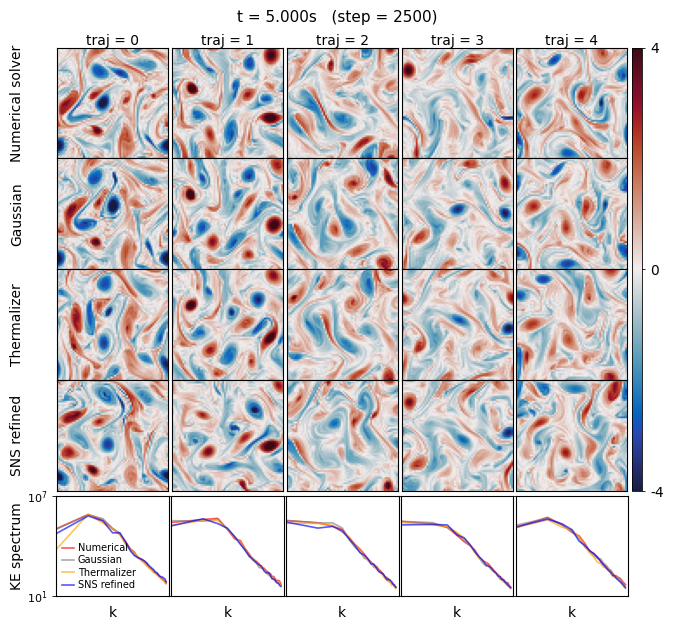

In [9]:
plot_snapshot_5traj_and_ke_spectra(tensor, step=2500, dt=0.002, savepath="snapshot_5traj.png")

In [3]:
import numpy as np
import matplotlib
matplotlib.use("Agg")  # headless / non-interactive backend
import matplotlib.pyplot as plt

from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator
from matplotlib.transforms import Bbox

from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
from tqdm import tqdm

import torch
import thermalizer.kolmogorov.util as util
import cmocean


def make_movie_snapshot_5traj(
    X_long,                              # (20, T, 64, 64)
    save_path="snapshot_5traj_movie.mp4",
    dt=0.002,
    fps=30,
    stride=10,
    steps=None,                          # optional explicit iterable of steps (overrides stride)
    traj_ids=(0, 1, 2, 3, 4),             # columns
    cmap="balance",
    vmin=-4.0,
    vmax=4.0,
    # labels / typography
    row_labels=("Numerical solver", "Gaussian", "Thermalizer", "SNS refined"),
    spec_label="KE spectrum",
    label_fs=10,
    title_pad=0.25,
    suptitle_y=0.985,
    # spectra axes
    ylim=(1e1, 1e7),
    xlim=(7e-1, 3.5e1),
    mean_lw=1.2,
    line_alpha=0.65,
    spec_ytick_fs=None,
    # sizing / spacing
    fig_w_per_col=1.25,
    fig_h=None,
    row_gap_cm=0.1,
    spectra_height_in=1.15,
    hspace_images=0.0,
    hspace_blocks=0.02,
    wspace=0.02,
    left=0.05,
    right=0.965,                         # leave room for colorbar on the far right
    top=0.94,
    bottom=0.065,
    spectra_block_ratio=0.42,
    # colorbar geometry (shared for the 4 image rows)
    cbar_gap=0.008,
    cbar_w=0.016,
    # movie writer
    bitrate="20000k",
    dpi=150,
    interpolation="nearest",
    # left label placement
    left_label_pad=0.015,                # in figure coords
):
    """
    Movie of snapshot figures.
    Each frame (single timestep) contains:
      - 4 image rows: Numerical / Gaussian / Thermalizer / SNS
      - 5 columns: 5 trajectories
      - 1 spectra row: KE spectrum (per trajectory) below
      - One global time suptitle
      - One shared colorbar for the image block
      - Figure-level left row labels aligned with BOTH image rows and spectra row
    """

    # ---------- helpers ----------
    def ensure_even_hw(rgb: np.ndarray) -> np.ndarray:
        """Pad (bottom/right) by 1 pixel if needed so H,W are even (libx264 requirement)."""
        if rgb.ndim != 3 or rgb.shape[2] != 3:
            raise ValueError(f"Expected RGB image [H,W,3], got {rgb.shape}")
        h, w = rgb.shape[:2]
        pad_h = h % 2
        pad_w = w % 2
        if pad_h == 0 and pad_w == 0:
            return rgb
        return np.pad(rgb, ((0, pad_h), (0, pad_w), (0, 0)), mode="edge")

    def to_numpy(a):
        return a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a)

    # ---------- convert input ----------
    if hasattr(X_long, "detach"):
        Xl_t = X_long.detach().cpu().to(dtype=torch.float32)
        Xl_n = Xl_t.numpy()
    else:
        Xl_n = np.asarray(X_long)
        Xl_t = torch.from_numpy(Xl_n).to(dtype=torch.float32, device="cpu")

    if Xl_n.ndim != 4 or Xl_n.shape[0] != 20 or Xl_n.shape[2:] != (64, 64):
        raise ValueError(f"Expected X_long shape (20, T, 64, 64), got {tuple(Xl_n.shape)}")

    T = Xl_n.shape[1]

    traj_ids = tuple(int(i) for i in traj_ids)
    if len(traj_ids) != 5:
        raise ValueError(f"`traj_ids` must have length 5, got {len(traj_ids)}")
    if any((i < 0 or i > 4) for i in traj_ids):
        raise ValueError("Each trajectory id must be in {0,1,2,3,4}.")

    # frame indices
    if steps is None:
        stride = max(1, int(stride))
        frame_indices = list(range(0, T, stride))
        if frame_indices[-1] != T - 1:
            frame_indices.append(T - 1)
    else:
        frame_indices = [int(s) for s in steps if 0 <= int(s) < T]
        if not frame_indices:
            raise ValueError("`steps` produced no valid indices in [0, T-1].")
        if frame_indices[-1] != T - 1:
            frame_indices.append(T - 1)

    # groups
    num_n, gau_n, thm_n, sns_n = Xl_n[0:5], Xl_n[5:10], Xl_n[10:15], Xl_n[15:20]
    num_t, gau_t, thm_t, sns_t = Xl_t[0:5], Xl_t[5:10], Xl_t[10:15], Xl_t[15:20]

    # spectra machinery
    grid = util.fourierGrid(64)

    def single_traj_spectrum(group_torch, traj_idx, step_idx):
        batch = group_torch[traj_idx:traj_idx + 1, step_idx].float()
        k, E = util.get_ke_batch(batch, grid)  # E: (1,Nk)
        return to_numpy(k), to_numpy(E)[0]

    colors = {"num": "red", "gau": "gray", "thm": "orange", "sns": "blue"}
    labels = {"num": "Numerical", "gau": "Gaussian", "thm": "Thermalizer", "sns": "SNS refined"}

    if spec_ytick_fs is None:
        spec_ytick_fs = max(1, label_fs - 2)

    cmap_obj = getattr(cmocean.cm, cmap)

    # ---------- build figure once ----------
    ncols = 5
    row_gap_in = row_gap_cm / 2.54
    img_block_h_in = 4.0 * fig_w_per_col + 3.0 * row_gap_in

    if fig_h is None:
        fig_h_use = img_block_h_in + spectra_height_in
        spec_block_h_in = spectra_height_in
    else:
        fig_h_use = fig_h
        spec_block_h_in = None

    fig = plt.figure(figsize=(fig_w_per_col * ncols, fig_h_use), dpi=dpi)

    if spec_block_h_in is not None:
        outer = fig.add_gridspec(2, 1, height_ratios=[img_block_h_in, spec_block_h_in], hspace=hspace_blocks)
    else:
        outer = fig.add_gridspec(2, 1, height_ratios=[4.0, spectra_block_ratio], hspace=hspace_blocks)

    fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom)

    gs_img = outer[0].subgridspec(4, ncols, hspace=hspace_images, wspace=wspace)
    gs_spec = outer[1].subgridspec(1, ncols, hspace=0.0, wspace=wspace)

    # global time title
    suptitle = fig.suptitle("", fontsize=label_fs + 1, y=suptitle_y)

    # images
    img_axes_all = []
    ims_img = [[None] * ncols for _ in range(4)]
    f0 = frame_indices[0]

    for col, tid in enumerate(traj_ids):
        axs = [fig.add_subplot(gs_img[r, col]) for r in range(4)]
        img_axes_all.extend(axs)

        ims_img[0][col] = axs[0].imshow(num_n[tid, f0], cmap=cmap_obj, vmin=vmin, vmax=vmax,
                                        interpolation=interpolation, origin="lower", aspect="equal")
        ims_img[1][col] = axs[1].imshow(gau_n[tid, f0], cmap=cmap_obj, vmin=vmin, vmax=vmax,
                                        interpolation=interpolation, origin="lower", aspect="equal")
        ims_img[2][col] = axs[2].imshow(thm_n[tid, f0], cmap=cmap_obj, vmin=vmin, vmax=vmax,
                                        interpolation=interpolation, origin="lower", aspect="equal")
        ims_img[3][col] = axs[3].imshow(sns_n[tid, f0], cmap=cmap_obj, vmin=vmin, vmax=vmax,
                                        interpolation=interpolation, origin="lower", aspect="equal")

        for ax in axs:
            ax.set_xticks([])
            ax.set_yticks([])

        axs[0].set_title(f"traj = {tid}", fontsize=label_fs, pad=title_pad)

    # shared colorbar for image block
    fig.canvas.draw()
    img_bbox = Bbox.union([ax.get_position() for ax in img_axes_all])
    cax_x0 = img_bbox.x1 + cbar_gap
    cax = fig.add_axes([cax_x0, img_bbox.y0, cbar_w, img_bbox.height])
    cbar = fig.colorbar(ims_img[0][0], cax=cax, orientation="vertical")
    cbar.set_ticks([vmin, 0.0, vmax])
    cbar.set_ticklabels([f"{vmin:g}", "0", f"{vmax:g}"])
    cbar.ax.tick_params(labelsize=label_fs, length=2, width=0.6)
    cbar.outline.set_linewidth(0.6)

    # spectra
    spec_axes = []
    spec_lines = []
    for col, tid in enumerate(traj_ids):
        ax = fig.add_subplot(
            gs_spec[0, col],
            sharex=spec_axes[0] if spec_axes else None,
            sharey=spec_axes[0] if spec_axes else None,
        )
        spec_axes.append(ax)

        line_dict = {}
        for key, group in (("num", num_t), ("gau", gau_t), ("thm", thm_t), ("sns", sns_t)):
            k, E = single_traj_spectrum(group, tid, f0)
            (ln,) = ax.loglog(k, E, color=colors[key], lw=mean_lw, alpha=line_alpha, label=labels[key])
            line_dict[key] = ln
        spec_lines.append(line_dict)

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        ax.set_xlabel("k", fontsize=label_fs)
        ax.xaxis.set_label_coords(0.5, -0.10)

        ax.yaxis.set_major_locator(FixedLocator([1e1, 1e7]))
        ax.yaxis.set_major_formatter(FixedFormatter([r"$10^1$", r"$10^7$"]))
        ax.yaxis.set_minor_locator(NullLocator())

        ax.xaxis.set_major_locator(NullLocator())
        ax.xaxis.set_minor_locator(NullLocator())
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

        ax.tick_params(axis="y", length=3, width=0.6, labelsize=spec_ytick_fs)
        if col != 0:
            ax.tick_params(labelleft=False)

        if col == 0:
            ax.legend(
                loc="lower left",
                frameon=False,
                fontsize=7,
                handlelength=1.2,
                handletextpad=0.4,
                borderpad=0.1,
                labelspacing=0.25,
            )

    # ---------- figure-level left labels aligned across image rows + spectra row ----------
    fig.canvas.draw()

    # centers of each image row (figure coords)
    row_centers = []
    for r in range(4):
        row_axes = [ims_img[r][c].axes for c in range(ncols)]
        bbox = Bbox.union([ax.get_position() for ax in row_axes])
        row_centers.append(0.5 * (bbox.y0 + bbox.y1))

    # center of spectra row
    spec_bbox = Bbox.union([ax.get_position() for ax in spec_axes])
    spec_center = 0.5 * (spec_bbox.y0 + spec_bbox.y1)

    # x position for all left labels (aligned)
    x_text = img_bbox.x0 - left_label_pad

    # add vertical left-side row labels (aligned like original y-labels)
    left_text_artists = []
    for y, lab in zip(row_centers, row_labels):
        left_text_artists.append(
            fig.text(
                x_text,
                y,
                lab,
                rotation=90,
                va="center",
                ha="center",
                fontsize=label_fs
            )
        )
    
    left_text_artists.append(
        fig.text(
            x_text,
            spec_center,
            spec_label,
            rotation=90,
            va="center",
            ha="center",
            fontsize=label_fs
        )
    )

    # ---------- render helpers ----------
    def fig_to_rgb_even():
        fig.canvas.draw()
        buf = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
        return ensure_even_hw(buf.copy())

    def update(i):
        f = frame_indices[i]
        suptitle.set_text(f"t = {f*dt:.3f}s   (step = {f})")

        # images
        for col, tid in enumerate(traj_ids):
            ims_img[0][col].set_data(num_n[tid, f])
            ims_img[1][col].set_data(gau_n[tid, f])
            ims_img[2][col].set_data(thm_n[tid, f])
            ims_img[3][col].set_data(sns_n[tid, f])

        # spectra
        for col, tid in enumerate(traj_ids):
            for key, group in (("num", num_t), ("gau", gau_t), ("thm", thm_t), ("sns", sns_t)):
                k, E = single_traj_spectrum(group, tid, f)
                spec_lines[col][key].set_data(k, E)

    # ---------- writer ----------
    first_frame = fig_to_rgb_even()
    h, w = first_frame.shape[:2]

    writer = FFMPEG_VideoWriter(
        filename=save_path,
        size=(w, h),
        fps=fps,
        codec="libx264",
        bitrate=bitrate,
        preset="medium",
        ffmpeg_params=["-pix_fmt", "yuv420p"],
    )

    try:
        for i in tqdm(range(len(frame_indices)), desc="Rendering movie"):
            update(i)
            frame = fig_to_rgb_even()
            writer.write_frame(frame)
    finally:
        writer.close()
        plt.close(fig)

    print(f"Movie saved: {save_path}")
    return save_path


# -----------------------
# Example usage
# -----------------------
# make_movie_snapshot_5traj(
#     tensor,                       # (20, T, 64, 64)
#     save_path="snapshots.mp4",
#     dt=0.002,
#     fps=20,
#     stride=5,
#     traj_ids=(0, 1, 2, 3, 4),
#     vmin=-4.0,
#     vmax=4.0,
# )

In [4]:
make_movie_snapshot_5traj(
    tensor,
    save_path="snapshots.mp4",
    dt=0.002,
    fps=20,
    stride=10,
    traj_ids=(0,1,2,3,4),
    vmin=-4.0,
    vmax=4.0,
)

/ext3/miniforge3/lib/python3.12/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
Rendering movie: 100%|██████████| 3001/3001 [14:57<00:00,  3.34it/s]


Movie saved: snapshots.mp4


'snapshots.mp4'

In [ ]:
steps = [0, 3000, 6000, 9000, 12000, 15000]

plot_rollout_and_ke_spectra(
    X_long = tensor,
    X_small = tensor_5,
    dt=0.002,
    steps=steps,
    savepath="paper.png",
    spectra_block_ratio=0.75
)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, FixedFormatter, NullLocator

import torch
import thermalizer.kolmogorov.util as util
import cmocean


def plot_rollout_and_ke_spectra(
    X,
    dt=0.002,
    steps=(0, 4000, 8000, 10000, 12000, 20000),
    cmap="balance",
    vmin=-4.0,
    vmax=4.0,
    row_labels=("Numerical solver", "Gaussian", "SNS refined"),
    ylim=(1e1, 1e7),
    xlim=(7e-1, 3.5e1),
    savepath="fig1.png",
    spread="logstd",
    spread_alpha=0.18,
    mean_lw=1.2,
    # NEW:
    group_size=None,          # if None, inferred as B//3
    image_member_idx=0,       # which member to plot in rollout images
):
    # -------------------------
    # Consistent numpy / torch views
    # -------------------------
    if torch.is_tensor(X):
        Xt = X.detach().cpu()
        Xn = Xt.numpy()
    else:
        Xn = np.asarray(X)
        Xt = torch.from_numpy(Xn).to(dtype=torch.float32, device="cpu")

    if Xn.ndim != 4:
        raise ValueError(f"Expected [B, T, H, W], got {Xn.shape}")

    B, T, H, W = Xn.shape
    if B % 3 != 0:
        raise ValueError(f"B must be divisible by 3 (num/emu/thr groups). Got B={B}")

    N = (B // 3) if group_size is None else int(group_size)
    if 3 * N > B:
        raise ValueError(f"group_size={N} implies 3*N={3*N} > B={B}")
    if 3 * N != B:
        # allow extra panels but keep a clean failure by default;
        # comment this out if you want to allow trailing items.
        raise ValueError(f"Expected B==3*N. Got B={B}, inferred/used N={N} => 3*N={3*N}")

    steps = tuple(int(s) for s in steps if 0 <= int(s) < T)
    if len(steps) == 0:
        raise ValueError("No valid `steps` within trajectory length T.")

    # Split into groups: each is [N, T, H, W]
    num_n, emu_n, thr_n = Xn[0:N], Xn[N:2*N], Xn[2*N:3*N]
    num_t, emu_t, thr_t = Xt[0:N], Xt[N:2*N], Xt[2*N:3*N]

    # Pick which member to show in images (only)
    if not (0 <= image_member_idx < N):
        raise ValueError(f"image_member_idx must be in [0, {N-1}], got {image_member_idx}")
    num0, emu0, thr0 = num_n[image_member_idx], emu_n[image_member_idx], thr_n[image_member_idx]

    ncols = len(steps)
    label_fs = 10

    cmap_obj = getattr(cmocean.cm, cmap) if isinstance(cmap, str) else cmap

    fig = plt.figure(figsize=(2.6 * ncols, 8.5))
    gs = fig.add_gridspec(4, ncols, hspace=0.15, wspace=0.01)

    # -------------------------
    # Rollout panels (FIRST of N only)
    # -------------------------
    for col, step in enumerate(steps):
        t_int = int(round(step * dt))  # (keeping your original behavior)

        axs = [fig.add_subplot(gs[r, col]) for r in range(3)]

        axs[0].imshow(num0[step], cmap=cmap_obj, vmin=vmin, vmax=vmax, origin="lower")
        axs[1].imshow(emu0[step], cmap=cmap_obj, vmin=vmin, vmax=vmax, origin="lower")
        axs[2].imshow(thr0[step], cmap=cmap_obj, vmin=vmin, vmax=vmax, origin="lower")

        for ax in axs:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_box_aspect(1)

        axs[0].set_title(f"t={t_int}s (step {step})", fontsize=label_fs)

        if col == 0:
            for ax, lab in zip(axs, row_labels):
                ax.set_ylabel(lab, fontsize=label_fs)

    # -------------------------
    # KE spectra (USE ALL N)
    # -------------------------
    grid = util.fourierGrid(64)

    def to_numpy(a):
        return a.detach().cpu().numpy() if torch.is_tensor(a) else np.asarray(a)

    def get_group_spectra(group, step):
        # group: [N, T, H, W]
        batch = group[:, step].float()   # [N, H, W]
        k, E = util.get_ke_batch(batch, grid)
        return to_numpy(k), to_numpy(E)  # E: [N, K] (typically)

    def mean_and_band(E):
        eps = 1e-30
        if spread == "minmax":
            return E.mean(0), E.min(0), E.max(0)
        logE = np.log(np.maximum(E, eps))
        mu, sd = logE.mean(0), logE.std(0)
        return np.exp(mu), np.exp(mu - sd), np.exp(mu + sd)

    colors = {"num": "red", "emu": "gray", "thr": "blue"}
    labels = {"num": "Numerical", "emu": "Gaussian", "thr": "SNS refined"}

    spectra = {
        (key, step): get_group_spectra(arr, step)
        for key, arr in zip(("num", "emu", "thr"), (num_t, emu_t, thr_t))
        for step in steps
    }

    # -------------------------
    # Spectra panels
    # -------------------------
    spec_axes = []
    for col, step in enumerate(steps):
        ax = fig.add_subplot(
            gs[3, col],
            sharex=spec_axes[0] if spec_axes else None,
            sharey=spec_axes[0] if spec_axes else None,
        )
        spec_axes.append(ax)
        ax.set_box_aspect(1)

        for key in ("num", "emu", "thr"):
            k, E = spectra[(key, step)]
            m, lo, hi = mean_and_band(E)
            ax.fill_between(k, lo, hi, color=colors[key], alpha=spread_alpha, lw=0)
            ax.loglog(k, m, color=colors[key], lw=mean_lw, label=labels[key])

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

        ax.set_xlabel("k", fontsize=label_fs)
        ax.xaxis.set_label_coords(0.5, -0.10)

        if col == 0:
            ax.set_ylabel("KE spectrum", fontsize=label_fs)

        ax.yaxis.set_major_locator(FixedLocator([1e1, 1e7]))
        ax.yaxis.set_major_formatter(FixedFormatter([r"$10^1$", r"$10^7$"]))
        ax.yaxis.set_minor_locator(NullLocator())

        ax.xaxis.set_major_locator(NullLocator())
        ax.xaxis.set_minor_locator(NullLocator())
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

        ax.tick_params(axis="y", length=3, width=0.6, labelsize=label_fs)
        if col != 0:
            ax.tick_params(labelleft=False)

        if col == 0:
            ax.legend(
                loc="lower left",
                frameon=False,
                fontsize=7,
                handlelength=1.2,
                handletextpad=0.4,
                borderpad=0.1,
                labelspacing=0.25,
            )

    fig.suptitle("Kolmogorov Flow", fontsize=12, y=0.96)
    plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()


In [14]:
plot_rollout_and_ke_spectra(tensor, image_member_idx=0)

NameError: name 'plot_rollout_and_ke_spectra' is not defined

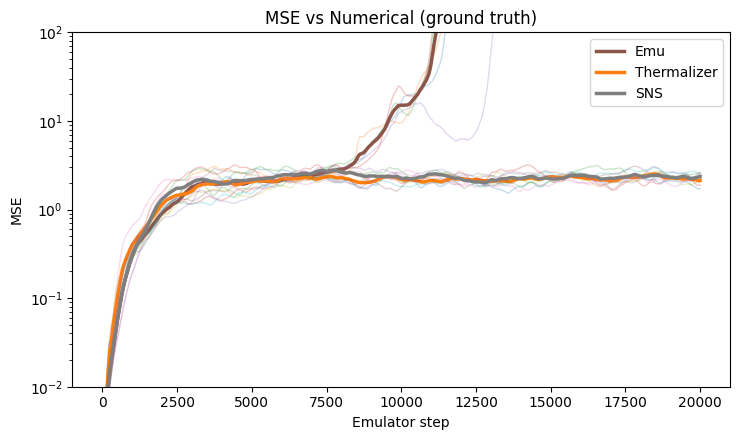

In [52]:
import numpy as np
import matplotlib.pyplot as plt

def plot_mse_all_on_one(
    runs,
    group_size=5,
    type_names=None,
    max_steps=10_000,
    stride=1,
    figsize=(7.5, 4.5),
    ylog=True,
    ylim=None,
    show_mean=True,
    mean_lw=2.5,
    indiv_lw=1.0,
    indiv_alpha=0.25,
    include_numerical=False,
    title=None,
    legend=True,
):
    """
    Plot MSE vs emulator step for ALL types on ONE axis, comparing each type
    to the numerical ground truth (type 0 block).

    runs shape: (N, T, H, W), with N = n_types * group_size.
    Block 0 (indices 0:group_size) is numerical (ground truth).
    For type k>0 replicate r, compare pred[r] to gt[r] (replicate-aligned).

    Each type is plotted as:
      - faint lines for each replicate (optional)
      - thick line for mean across replicates (optional)

    Returns: fig, ax
    """
    # --- convert to numpy ---
    if hasattr(runs, "detach"):  # torch.Tensor
        runs = runs.detach().cpu().numpy()
    else:
        runs = np.asarray(runs)

    assert runs.ndim == 4, f"Expected (N,T,H,W), got shape {runs.shape}"
    N, T, H, W = runs.shape
    assert N % group_size == 0, "N must be divisible by group_size."
    n_types = N // group_size
    assert n_types >= 2, "Need at least numerical + one model type."

    if type_names is None:
        type_names = ["Numerical"] + [f"Type {k}" for k in range(1, n_types)]
    else:
        assert len(type_names) == n_types, "type_names must match number of type blocks."

    # --- time indexing ---
    Tplot = min(T, max_steps)
    tidx = np.arange(0, Tplot, stride)
    x = tidx

    # --- blocks ---
    gt_block = runs[0:group_size, :Tplot]  # (group_size, Tplot, H, W)

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Optional: plot numerical self-error (zero line) if desired
    if include_numerical:
        ax.plot(x, np.zeros_like(x, dtype=float), label=type_names[0])

    for k in range(1, n_types):
        r0, r1 = k * group_size, (k + 1) * group_size
        pred_block = runs[r0:r1, :Tplot]

        # mse: (group_size, Tplot)
        mse = ((pred_block - gt_block) ** 2).mean(axis=(2, 3))

        # plot replicates (faint)
        for r in range(group_size):
            ax.plot(x, mse[r, tidx], linewidth=indiv_lw, alpha=indiv_alpha)

        # plot mean (thick) with label
        if show_mean:
            ax.plot(
                x,
                mse[:, tidx].mean(axis=0),
                linewidth=mean_lw,
                label=type_names[k],
            )

    ax.set_xlabel("Emulator step")
    ax.set_ylabel("MSE")
    if ylog:
        ax.set_yscale("log")
    if ylim is not None:
        ax.set_ylim(*ylim)
    if title is not None:
        ax.set_title(title)
    if legend and show_mean:
        ax.legend()

    fig.tight_layout()
    return fig, ax


# -------------------------
# Example:
fig, ax = plot_mse_all_on_one(
    runs = tensor,                      # (20, 30000, 64, 64)
    group_size=5,
    type_names=["Numerical", "Emu", "Thermalizer", "SNS"],
    max_steps=20000,
    stride=1,
    ylim=(1e-2, 1e2),
    title="MSE vs Numerical (ground truth)",
)
plt.show()


In [33]:
import numpy as np

def _to_numpy(x):
    if hasattr(x, "detach"):  # torch.Tensor
        return x.detach().cpu().numpy()
    return np.asarray(x)

def _isotropized_2d_power_spectrum(field2d, nbins=None, kmax=None):
    """
    Radially-binned (isotropic) 2D power spectrum of a real 2D field.
    Returns (k_centers, E_k), where E_k is the mean power in each k-bin.
    """
    f = np.asarray(field2d)
    assert f.ndim == 2, f"field2d must be 2D, got {f.shape}"
    ny, nx = f.shape

    F = np.fft.rfft2(f)                       # shape (ny, nx//2+1)
    P = (F.real**2 + F.imag**2)               # power

    ky = np.fft.fftfreq(ny) * ny              # integer-like wavenumbers
    kx = np.fft.rfftfreq(nx) * nx
    KY, KX = np.meshgrid(ky, kx, indexing="ij")
    K = np.sqrt(KX**2 + KY**2)

    k_flat = K.ravel()
    p_flat = P.ravel()

    # choose bins
    if kmax is None:
        kmax = k_flat.max()
    if nbins is None:
        nbins = int(min(ny, nx) // 2)

    bins = np.linspace(0.0, kmax, nbins + 1)
    which = np.digitize(k_flat, bins) - 1  # 0..nbins-1

    E = np.zeros(nbins, dtype=float)
    C = np.zeros(nbins, dtype=float)

    valid = (which >= 0) & (which < nbins)
    which = which[valid]
    p_flat = p_flat[valid]

    # accumulate
    np.add.at(E, which, p_flat)
    np.add.at(C, which, 1.0)

    # mean power per bin
    E = np.divide(E, C, out=np.zeros_like(E), where=C > 0)

    k_centers = 0.5 * (bins[:-1] + bins[1:])
    return k_centers, E

def _spectrum_distance(Ea, Eb, kind="rel_l2", eps=1e-30):
    """
    Distance between 1D spectra Ea and Eb (same length).
      - "rel_l2": ||Ea-Eb||_2 / ||Eb||_2
      - "l2":     ||Ea-Eb||_2
      - "log_l2": ||log(Ea)-log(Eb)||_2   (uses eps to avoid log(0))
      - "log_rel_l2": ||log(Ea)-log(Eb)||_2 / ||log(Eb)||_2
    """
    Ea = np.asarray(Ea, dtype=float)
    Eb = np.asarray(Eb, dtype=float)
    assert Ea.shape == Eb.shape

    if kind == "l2":
        return np.linalg.norm(Ea - Eb)
    if kind == "rel_l2":
        return np.linalg.norm(Ea - Eb) / (np.linalg.norm(Eb) + eps)
    if kind == "log_l2":
        return np.linalg.norm(np.log(Ea + eps) - np.log(Eb + eps))
    if kind == "log_rel_l2":
        return np.linalg.norm(np.log(Ea + eps) - np.log(Eb + eps)) / (np.linalg.norm(np.log(Eb + eps)) + eps)

    raise ValueError(f"Unknown kind={kind}")

def compute_temporal_mean_spectrum_distances(
    runs,
    group_size=5,
    type_map=None,
    time_slice=None,
    nbins=None,
    kmax=None,
    distance_kind="log_l2",
    eps=1e-30,
):
    """
    Compute spectrum distances between temporally-averaged fields for selected types.

    Your tensor: runs shape (N, T, H, W), N = n_types*group_size.
    Block 0 is numerical. You want distances among:
      - numerical temporal mean
      - thermalization temporal mean
      - SNS temporal mean

    Parameters
    ----------
    runs : np.ndarray or torch.Tensor
        Shape (N,T,H,W).
    group_size : int
        Replicates per type block (you said 5).
    type_map : dict[str,int]
        Mapping from name -> type_block_index, e.g.
        {"numerical": 0, "thermalization": 1, "SNS": 2}
        If None, defaults to that exact mapping.
    time_slice : slice or tuple or None
        Time window to average over. Examples:
          - None -> all times
          - slice(0, 10_000) -> first 10k
          - (t0, t1) -> uses slice(t0,t1)
    nbins, kmax : spectrum binning controls
    distance_kind : str
        One of {"l2","rel_l2","log_l2","log_rel_l2"}.
    eps : float
        Small value for log distances.

    Returns
    -------
    out : dict
        {
          "k": k_centers,
          "spectra": {name: E_k_mean_over_replicates},
          "distances": {("thermalization","numerical"): d, ("SNS","numerical"): d, ("SNS","thermalization"): d}
        }
    """
    runs = _to_numpy(runs)
    assert runs.ndim == 4, f"Expected (N,T,H,W), got {runs.shape}"
    N, T, H, W = runs.shape
    assert N % group_size == 0, "N must be divisible by group_size."
    n_types = N // group_size

    if type_map is None:
        type_map = {"numerical": 0, "thermalization": 1, "SNS": 2}

    for name, idx in type_map.items():
        if not (0 <= idx < n_types):
            raise ValueError(f"type_map['{name}']={idx} out of range (n_types={n_types}).")

    if time_slice is None:
        ts = slice(None)
    elif isinstance(time_slice, tuple):
        ts = slice(time_slice[0], time_slice[1])
    else:
        ts = time_slice

    # 1) temporally average each replicate (per type)
    # 2) compute isotropized spectrum per replicate
    # 3) average spectra across replicates within each type
    spectra_mean = {}
    k_ref = None

    for name, type_idx in type_map.items():
        block = runs[type_idx * group_size : (type_idx + 1) * group_size, ts, :, :]  # (R, t, H, W)
        R = block.shape[0]

        Ek_list = []
        for r in range(R):
            tm = block[r].mean(axis=0)  # (H,W): temporal mean field
            k, Ek = _isotropized_2d_power_spectrum(tm, nbins=nbins, kmax=kmax)
            if k_ref is None:
                k_ref = k
            else:
                # ensure identical binning
                if len(k) != len(k_ref) or np.max(np.abs(k - k_ref)) > 1e-12:
                    raise RuntimeError("Spectrum binning mismatch; fix by passing explicit nbins/kmax.")
            Ek_list.append(Ek)

        spectra_mean[name] = np.mean(np.stack(Ek_list, axis=0), axis=0)

    # distances (pairwise among requested)
    names = list(type_map.keys())
    dists = {}
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            a, b = names[i], names[j]
            d = _spectrum_distance(spectra_mean[a], spectra_mean[b], kind=distance_kind, eps=eps)
            dists[(a, b)] = d

    return {"k": k_ref, "spectra": spectra_mean, "distances": dists}


# -------------------------
# Example usage:
# runs: (20, 30000, 64, 64)
#
out = compute_temporal_mean_spectrum_distances(
    runs = tensor,
    group_size=5,
    type_map={"numerical": 0, "thermalization": 1, "SNS": 2},
    time_slice=(0, 10000),      # average over first 10k steps (optional)
    nbins=32,                   # optional: explicit bins for reproducibility
    distance_kind="log_l2",      # good default for spectra
)

print("Distances:")
for (a,b), d in out["distances"].items():
    print(f"{a} vs {b}: {d:.6g}")

# # If you want the spectra to plot later:
# k = out["k"]
# En = out["spectra"]["numerical"]
# Et = out["spectra"]["thermalization"]
# Es = out["spectra"]["SNS"]


Distances:
numerical vs thermalization: 12.3541
numerical vs SNS: 0.931216
thermalization vs SNS: 12.1788


In [53]:
import numpy as np
import matplotlib.pyplot as plt

def plot_mean_spectra(
    spectrum_output,
    order=("numerical", "emulator", "thermalization", "SNS"),
    labels=None,
    figsize=(6.5, 4.5),
    loglog=True,
    ylim=None,
    xlim=None,
    title=None,
    legend=True,
):
    """
    Plot averaged isotropic spectra for multiple fields on one plot.

    Parameters
    ----------
    spectrum_output : dict
        Output from compute_temporal_mean_spectrum_distances():
        {
          "k": k_centers,
          "spectra": {name: E_k}
        }
    order : tuple[str]
        Order in which spectra are plotted.
    labels : dict or None
        Optional mapping name -> label for legend.
    figsize : tuple
        Figure size.
    loglog : bool
        Use log-log axes.
    ylim, xlim : tuple or None
        Axis limits.
    title : str or None
        Plot title.
    legend : bool
        Show legend.

    Returns
    -------
    fig, ax
    """
    k = spectrum_output["k"]
    spectra = spectrum_output["spectra"]

    if labels is None:
        labels = {name: name for name in order}

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    for name in order:
        if name not in spectra:
            raise KeyError(f"Spectrum '{name}' not found in spectrum_output.")
        ax.plot(k, spectra[name], linewidth=2, label=labels.get(name, name))

    ax.set_xlabel(r"Wavenumber $k$")
    ax.set_ylabel(r"Isotropic power spectrum $E(k)$")

    if loglog:
        ax.set_xscale("log")
        ax.set_yscale("log")

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    if title is not None:
        ax.set_title(title)

    if legend:
        ax.legend()

    fig.tight_layout()
    return fig, ax


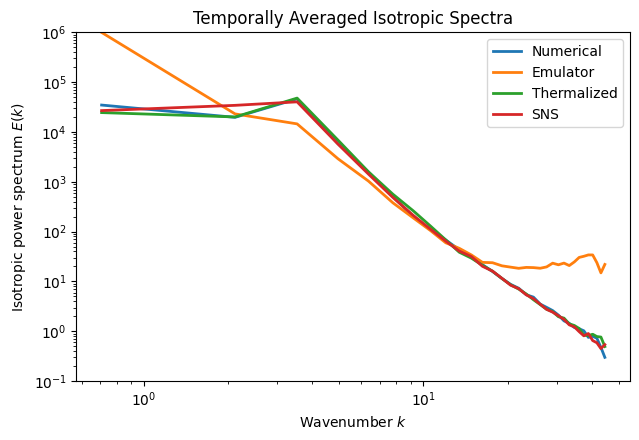

In [54]:
out = compute_temporal_mean_spectrum_distances(
    runs= tensor,
    group_size=5,
    type_map={
        "numerical": 0,
        "emulator": 1,
        "thermalization": 2,
        "SNS": 3,
    },
    time_slice=(0, 10000),
    nbins=32,
    distance_kind="log_l2",
)

fig, ax = plot_mean_spectra(
    out,
    order=("numerical", "emulator", "thermalization", "SNS"),
    labels={
        "numerical": "Numerical",
        "emulator": "Emulator",
        "thermalization": "Thermalized",
        "SNS": "SNS",
    },
    title="Temporally Averaged Isotropic Spectra",
    ylim=(1e-1, 1e6),   # adjust as needed
)
plt.show()


In [1]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
from tqdm import tqdm

from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter


def make_movie_moviepy_qg_5x3_with_member_spectra(
    state_vector,                                  # [15, T, 2, H, W] = 5 numerical + 5 emulation + 5 SNS
    save_path="qg_5x3_first5_plus_member_spectra.mp4",
    fps=30,
    stride=10,
    dt=36000.0,                                    # seconds per model step

    # --- column titles (only once, top row only) ---
    col_titles=None,                               # len 5, defaults to Trajectory 1..5

    method_names=("Numerical", "Emulation", "SNS"),
    layer_names=("Top", "Bottom"),
    cmap="viridis",
    interpolation="nearest",
    dpi=150,
    bitrate="20000k",
    origin="upper",

    # --- fixed image color scaling ---
    vmin=-4.0,
    vmax=4.0,

    # --- layout ---
    hspace=0.15,
    wspace=0.10,
    suptitle=None,                                 # None -> show timestep+time; str -> fixed title
    suptitle_y=0.97,
    top_margin=0.9,
    cbar_width=0.008,
    cbar_pad=0.008,

    # --- spectra ---
    Lx=1.0,
    Ly=1.0,
    k_units="cyc",          # "cyc" or "rad"
    field_type="psi",       # "psi" -> KE ~ 0.5*k^2*|psi_hat|^2 ; else -> ~0.5*|hat|^2/k^2
    spec_logx=True,
    spec_logy=True,
    spec_xlim=(1.0, 32.0),
    spec_ylim=None,
    spectra_nbins=None,
    spectra_linewidth=1.2,
):
    """
    Movie layout (8 rows x 5 cols):
      - Rows 0..5: images for (method, layer), showing 5 trajectories per type (5 cols).
      - Rows 6..7: KE power spectra (Top then Bottom), plotted for individual trajectories.
                   Each column c corresponds to trajectory c (0..4). Each spectra axis has 3 lines:
                   Numerical, Emulation, SNS.

    Expected input shape:
        [15, T, 2, H, W]
    with ordering:
        0..4   -> Numerical
        5..9   -> Emulation
        10..14 -> SNS
    """

    # -------------------------
    # Numpy view
    # -------------------------
    if hasattr(state_vector, "detach"):
        arr = state_vector.detach().cpu().numpy()
    else:
        arr = np.asarray(state_vector)

    if arr.ndim != 5:
        raise ValueError(f"Expected [15, T, 2, H, W], got {arr.shape}")
    B, T, L, H, W = arr.shape
    if B != 15:
        raise ValueError(f"Expected B=15 (3*5), got B={B}")
    if L != 2:
        raise ValueError(f"Expected L=2 layers, got L={L}")
    if T < 1:
        raise ValueError("T must be >= 1")

    n_methods = 3
    members_per_method = 5
    ncols = 5
    n_image_rows = n_methods * 2  # 6
    nrows_total = 8               # 6 image rows + 2 spectra rows

    stride = max(1, int(stride))
    frame_indices = list(range(0, T, stride))
    if frame_indices[-1] != T - 1:
        frame_indices.append(T - 1)

    if col_titles is None:
        col_titles = [f"Trajectory {i+1}" for i in range(ncols)]
    if len(col_titles) != ncols:
        raise ValueError("`col_titles` must have length 5.")
    if len(method_names) != 3:
        raise ValueError("`method_names` must have length 3.")
    if len(layer_names) != 2:
        raise ValueError("`layer_names` must have length 2.")

    def bidx(method, mem):
        # method in {0,1,2}, mem in {0..4}
        return method * members_per_method + mem

    def row_to_method_layer(r):
        # r in {0..5}
        method = r // 2
        layer = r % 2
        return method, layer

    # -------------------------
    # Fixed image color limits
    # -------------------------
    row_limits = [(float(vmin), float(vmax))] * n_image_rows

    # -------------------------
    # Spectrum prep
    # -------------------------
    dx, dy = Lx / W, Ly / H
    kx = np.fft.fftfreq(W, d=dx)
    ky = np.fft.fftfreq(H, d=dy)
    if k_units == "rad":
        kx *= 2 * np.pi
        ky *= 2 * np.pi

    KX, KY = np.meshgrid(kx, ky, indexing="xy")
    K2 = KX**2 + KY**2
    K = np.sqrt(K2)

    nbins = int(max(H, W) if spectra_nbins is None else spectra_nbins)
    edges = np.linspace(0.0, float(K.max()), nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_idx = np.digitize(K, edges) - 1
    valid = (K > 0) & (bin_idx >= 0) & (bin_idx < nbins)

    def ke_spectrum_binned(field_2d):
        """
        Returns binned isotropic KE spectrum E(k) on `centers` for a single 2D field.
        """
        fhat = np.fft.fft2(field_2d)
        power = (np.abs(fhat) ** 2) / (H * W) ** 2

        if field_type == "psi":
            Ek = 0.5 * K2 * power
        else:
            Ek = 0.5 * power / np.where(K2 == 0, np.nan, K2)

        Ebin = np.bincount(
            bin_idx[valid].ravel(),
            weights=Ek[valid].ravel(),
            minlength=nbins,
        )
        return Ebin

    def member_spectra_at_time(t, ell, mem):
        """
        Returns list length 3: [E_numerical, E_emulation, E_sns]
        for the same trajectory index `mem` in each method block.
        """
        out = []
        for m in range(n_methods):
            field = arr[bidx(m, mem), t, ell, :, :]
            if not np.all(np.isfinite(field)):
                out.append(np.full(nbins, np.nan))
            else:
                out.append(ke_spectrum_binned(field))
        return out

    # -------------------------
    # Figure / gridspec
    # -------------------------
    fig = plt.figure(figsize=(2.6 * ncols + 1.0, 2.1 * nrows_total), dpi=dpi)
    gs = fig.add_gridspec(nrows_total, ncols, hspace=hspace, wspace=wspace)

    fig.subplots_adjust(top=top_margin)

    ims = [[None] * ncols for _ in range(n_image_rows)]
    image_axes_lastcol = []

    # --- image rows (0..5) ---
    for r in range(n_image_rows):
        m, ell = row_to_method_layer(r)
        vmin_r, vmax_r = row_limits[r]

        for c in range(ncols):
            ax = fig.add_subplot(gs[r, c])
            b = bidx(m, c)
            data0 = arr[b, frame_indices[0], ell, :, :]

            im = ax.imshow(
                data0,
                cmap=cmap,
                vmin=vmin_r,
                vmax=vmax_r,
                interpolation=interpolation,
                origin=origin,
            )
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_box_aspect(1)

            if r == 0:
                ax.set_title(col_titles[c], fontsize=10)
            else:
                ax.set_title("")

            if c == 0:
                ax.set_ylabel(f"{method_names[m]}\n{layer_names[ell]}", fontsize=10)

            if c == ncols - 1:
                image_axes_lastcol.append((ax, im))

            ims[r][c] = im

    # --- external colorbars (one per image row) ---
    for r in range(n_image_rows):
        ax_last, im_last = image_axes_lastcol[r]
        pos = ax_last.get_position()
        cax = fig.add_axes([pos.x1 + cbar_pad, pos.y0, cbar_width, pos.height])
        cb = fig.colorbar(im_last, cax=cax)
        cb.outline.set_visible(False)
        cb.ax.tick_params(labelsize=7, length=2, width=0.5)

    # --- spectra rows (6..7) ---
    spec_lines = [[None] * ncols for _ in range(2)]  # [ell][col] -> list of 3 lines

    for ell in (0, 1):
        row = 6 + ell
        for c in range(ncols):
            ax = fig.add_subplot(gs[row, c])
            ax.set_box_aspect(1)
            ax.grid(True, which="both", alpha=0.2)

            if spec_logx:
                ax.set_xscale("log")
            if spec_logy:
                ax.set_yscale("log")

            ax.set_xlim(*spec_xlim)
            if spec_ylim is not None:
                ax.set_ylim(*spec_ylim)

            lines = []
            for m in range(n_methods):
                (ln,) = ax.plot([], [], lw=spectra_linewidth, label=method_names[m])
                lines.append(ln)

            if c == 0:
                ax.set_ylabel(f"KE spectrum\n{layer_names[ell]}", fontsize=10)

            if ell == 0:
                ax.set_xticks([])
                ax.set_xticks([], minor=True)
                ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
            else:
                ax.set_xlabel("k", fontsize=9)
                ax.xaxis.set_major_locator(LogLocator(base=10))
                ax.xaxis.set_major_formatter(LogFormatterMathtext())
                ax.xaxis.set_minor_formatter(NullFormatter())
                ax.tick_params(axis="x", which="major", labelsize=7, length=3, width=0.6)
                ax.tick_params(axis="x", which="minor", length=2, width=0.4)

            ax.tick_params(axis="y", which="both", labelleft=False)
            if c == 0:
                ax.tick_params(axis="y", which="both", left=True, length=3, width=0.6)
            else:
                ax.tick_params(axis="y", which="both", left=False)

            if ell == 1 and c == ncols - 1:
                ax.legend(frameon=False, fontsize=8)

            spec_lines[ell][c] = lines

    # --- suptitle ---
    t0 = frame_indices[0]
    time0 = t0 * dt
    if isinstance(suptitle, str):
        title_text0 = suptitle
    else:
        title_text0 = f"Timestep = {t0}   |   Time = {time0:.3e} s"

    title_obj = fig.suptitle(title_text0, fontsize=12, y=suptitle_y)

    fig.canvas.draw()

    def fig_to_rgb():
        fig.canvas.draw()
        buf = np.asarray(fig.canvas.buffer_rgba())
        return buf[:, :, :3].copy()

    def update(frame_i):
        t = frame_indices[frame_i]

        # --- update images ---
        for r in range(n_image_rows):
            m, ell = row_to_method_layer(r)
            for c in range(ncols):
                b = bidx(m, c)
                ims[r][c].set_data(arr[b, t, ell, :, :])

        # --- update spectra ---
        xmin, xmax = spec_xlim
        mask = (centers >= xmin) & (centers <= xmax)
        x = centers[mask]

        for ell in (0, 1):
            for c in range(ncols):
                E_by_method = member_spectra_at_time(t, ell, c)
                lines = spec_lines[ell][c]
                for m in range(n_methods):
                    y = E_by_method[m][mask]
                    lines[m].set_data(x, y)

        # --- update title ---
        if not isinstance(suptitle, str):
            time = t * dt
            title_obj.set_text(f"Timestep = {t}   |   Time = {time:.3e} s")

    # init first frame
    update(0)
    first_frame = fig_to_rgb()
    height, width = first_frame.shape[:2]

    writer = FFMPEG_VideoWriter(
        filename=save_path,
        size=(width, height),
        fps=fps,
        codec="libx264",
        bitrate=bitrate,
        preset="medium",
        ffmpeg_params=["-pix_fmt", "yuv420p"],
    )

    try:
        for i in tqdm(range(len(frame_indices)), desc="Rendering movie"):
            update(i)
            writer.write_frame(fig_to_rgb())
    finally:
        writer.close()
        plt.close(fig)

    print(f"Movie saved: {save_path}")

In [2]:
import torch
tensor_1 = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/long_qg_rollouts.pt", map_location=torch.device('cpu'))["data"]    
upper_std=7.6382e-06
lower_std=3.0120e-07
tensor_1[:,:,0,:,:]/=upper_std
tensor_1[:,:,1,:,:]/=lower_std
tensor_2 = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/FINAL_PAPER_QG_EMU.p", map_location=torch.device('cpu'))            
tensor_3 = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/FINAL_PAPER_QG.p", map_location=torch.device('cpu'))     

/state/partition1/job-4388264/ipykernel_90491/1736220995.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor_1 = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/long_qg

In [3]:
tensor_2.shape

torch.Size([5, 20000, 2, 64, 64])

In [4]:
tensor = torch.cat((tensor_1[:,:20000],tensor_2,tensor_3[0]), dim = 0)

In [5]:
import cmocean
make_movie_moviepy_qg_5x3_with_member_spectra(
    tensor,
    save_path="qg_20x3_first5_plus_avg_spectra.mp4",

    fps=30,
    stride=20,
    vmin=-4, vmax=4,

    method_names=("Numerical", "Gaussian", "SNS refined"),
    layer_names=("Top Layber", "Bottom Layer"),

    cmap=cmocean.cm.balance,
    interpolation="nearest",

    # match your plotting layout spacing
    hspace=0.10,
    wspace=0.10,

    # spectra settings (same style as your static plot)
    Lx=1.0,
    Ly=1.0,
    k_units="cyc",
    spec_logx=True,
    spec_logy=True,
    spec_xlim=(1, 60),
    spec_ylim = (1e-4, 1e1)
)

Rendering movie: 100%|██████████| 1001/1001 [10:19<00:00,  1.62it/s]


Movie saved: qg_20x3_first5_plus_avg_spectra.mp4
